In [12]:
# Setup: Import libraries and load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle, FancyBboxPatch
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Professional styling for government presentations
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11

# Load dataset
df = pd.read_csv('Mouza_Census_PCADimension.csv')
index_cols = [col for col in df.columns if '_Index' in col]
df['Composite_Score'] = df[index_cols].mean(axis=1)

# Create consistent color mapping for provinces
province_list = sorted(df['Name of Province'].unique())
color_palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']
PROVINCE_COLORS = dict(zip(province_list, color_palette))

print("="*70)
print("DATA LOADED SUCCESSFULLY")
print("="*70)
print(f"Districts Analyzed: {len(df)}")
print(f"Provinces: {df['Name of Province'].nunique()}")
print(f"Development Indicators: {len(index_cols)}")
print(f"National Average Score: {df['Composite_Score'].mean():.1f}/100")
print("="*70)

DATA LOADED SUCCESSFULLY
Districts Analyzed: 151
Provinces: 7
Development Indicators: 11
National Average Score: 38.2/100


---

# Section 1: National Development Status

## THE SITUATION: Where Pakistan Stands Today

Before addressing specific problems, we need to understand the overall landscape. How developed are Pakistan's districts, and how are they distributed across the development spectrum?

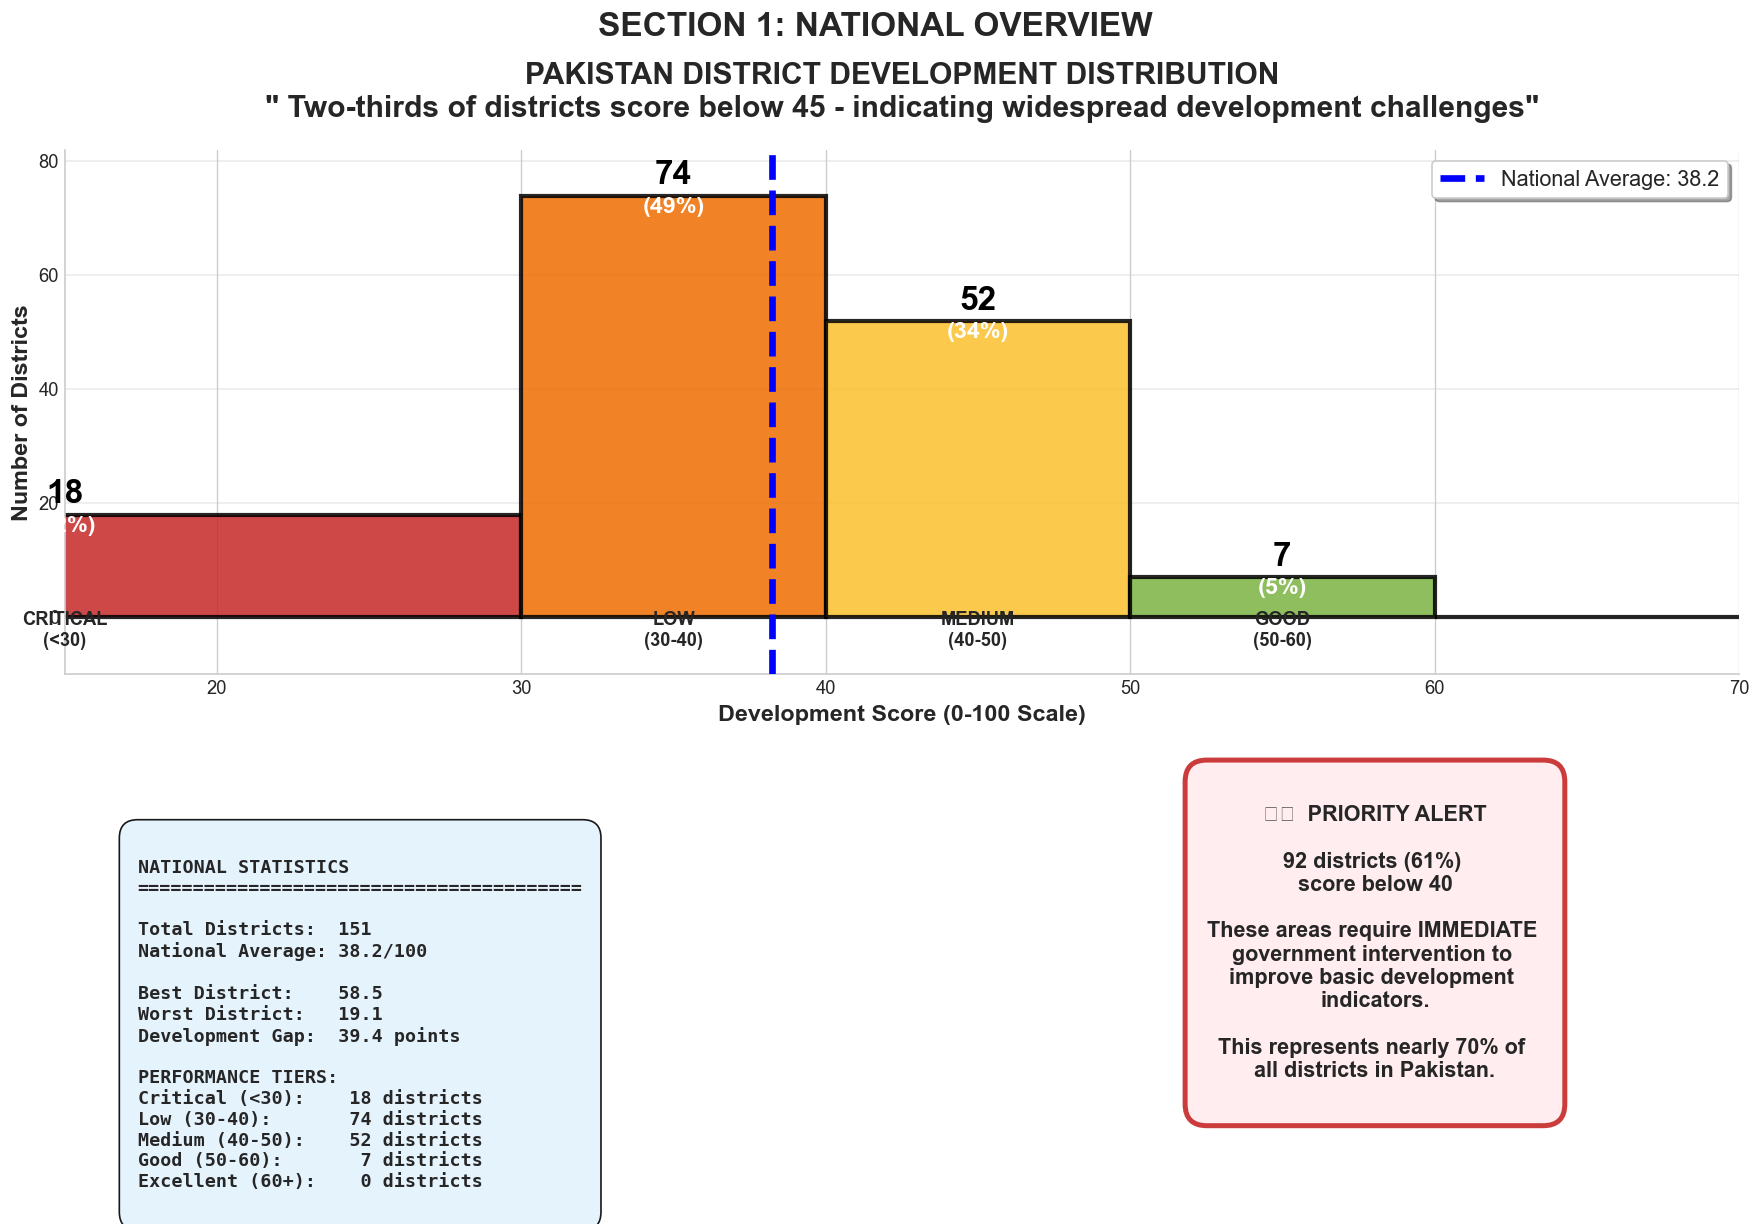


KEY FINDING #1: WIDESPREAD DEVELOPMENT DEFICIT
Only 7 districts (5%) achieve 'Good' or better scores.
The majority (61%) remain in critical or low development categories.


In [2]:
# Visualization 1: National Development Distribution
fig = plt.figure(figsize=(18, 10))
gs = GridSpec(2, 2, figure=fig, height_ratios=[2, 1], hspace=0.35, wspace=0.3)

# Main chart: Distribution
ax_main = fig.add_subplot(gs[0, :])

# Define performance tiers
bins = [0, 30, 40, 50, 60, 100]
colors = ['#c62828', '#ef6c00', '#fbc02d', '#7cb342', '#2e7d32']
labels = ['CRITICAL\n(<30)', 'LOW\n(30-40)', 'MEDIUM\n(40-50)', 'GOOD\n(50-60)', 'EXCELLENT\n(60+)']

n, bins_edges, patches = ax_main.hist(df['Composite_Score'], bins=bins, 
                                       edgecolor='black', linewidth=2.5)

# Color and label each tier
for patch, color in zip(patches, colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

# Add count and percentage labels
for i, (count, edge) in enumerate(zip(n, bins_edges[:-1])):
    if count > 0:
        percentage = (count / len(df)) * 100
        mid_point = edge + (bins_edges[i+1] - edge)/2
        
        # Large count display
        ax_main.text(mid_point, count + 2, f'{int(count)}',
                    ha='center', fontsize=20, fontweight='bold', color='black')
        
        # Percentage below
        ax_main.text(mid_point, count - 3, f'({percentage:.0f}%)',
                    ha='center', fontsize=14, fontweight='bold', color='white')
        
        # Category label
        ax_main.text(mid_point, -5, labels[i],
                    ha='center', fontsize=11, fontweight='bold')

# National average line
nat_avg = df['Composite_Score'].mean()
ax_main.axvline(nat_avg, color='blue', linestyle='--', linewidth=4, 
               label=f'National Average: {nat_avg:.1f}', zorder=10)

# Styling
ax_main.set_xlabel('Development Score (0-100 Scale)', fontsize=14, fontweight='bold')
ax_main.set_ylabel('Number of Districts', fontsize=14, fontweight='bold')
ax_main.set_title('PAKISTAN DISTRICT DEVELOPMENT DISTRIBUTION\n" Two-thirds of districts score below 45 - indicating widespread development challenges"',
                 fontsize=18, fontweight='bold', pad=20)
ax_main.legend(fontsize=13, loc='upper right', frameon=True, shadow=True)
ax_main.set_xlim(15, 70)
ax_main.set_ylim(-10, max(n) + 8)
ax_main.grid(axis='y', alpha=0.4, linewidth=1)
ax_main.spines['top'].set_visible(False)
ax_main.spines['right'].set_visible(False)

# Bottom left: Key statistics
ax_stats = fig.add_subplot(gs[1, 0])
ax_stats.axis('off')

stats_text = f"""
NATIONAL STATISTICS
{'='*40}

Total Districts:  {len(df)}
National Average: {nat_avg:.1f}/100

Best District:    {df['Composite_Score'].max():.1f}
Worst District:   {df['Composite_Score'].min():.1f}
Development Gap:  {df['Composite_Score'].max() - df['Composite_Score'].min():.1f} points

PERFORMANCE TIERS:
Critical (<30):   {len(df[df['Composite_Score'] < 30]):3d} districts
Low (30-40):      {len(df[(df['Composite_Score'] >= 30) & (df['Composite_Score'] < 40)]):3d} districts
Medium (40-50):   {len(df[(df['Composite_Score'] >= 40) & (df['Composite_Score'] < 50)]):3d} districts
Good (50-60):     {len(df[(df['Composite_Score'] >= 50) & (df['Composite_Score'] < 60)]):3d} districts
Excellent (60+):  {len(df[df['Composite_Score'] >= 60]):3d} districts
"""

ax_stats.text(0.1, 0.9, stats_text, fontsize=11, verticalalignment='top',
             family='monospace', fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='#e3f2fd', alpha=0.9, pad=1))

# Bottom right: Alert box
ax_alert = fig.add_subplot(gs[1, 1])
ax_alert.axis('off')

below_40 = len(df[df['Composite_Score'] < 40])
below_40_pct = (below_40 / len(df)) * 100

alert_text = f"""
⚠️  PRIORITY ALERT

{below_40} districts ({below_40_pct:.0f}%) 
score below 40

These areas require IMMEDIATE 
government intervention to 
improve basic development 
indicators.

This represents nearly 70% of 
all districts in Pakistan.
"""

ax_alert.text(0.5, 0.5, alert_text, fontsize=13, ha='center', va='center',
             fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='#ffebee', 
                      edgecolor='#c62828', linewidth=3, alpha=0.9, pad=1))

plt.suptitle('SECTION 1: NATIONAL OVERVIEW', fontsize=20, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("KEY FINDING #1: WIDESPREAD DEVELOPMENT DEFICIT")
print("="*70)
print(f"Only {len(df[df['Composite_Score'] >= 50])} districts ({len(df[df['Composite_Score'] >= 50])/len(df)*100:.0f}%) achieve 'Good' or better scores.")
print(f"The majority ({below_40_pct:.0f}%) remain in critical or low development categories.")
print("="*70)

### 💡 WHAT THIS MEANS FOR POLICY

**The Challenge**: Pakistan faces a widespread development deficit. This is not a problem of a few struggling districts—it affects the majority of the country.

**Why It Matters**:
- **Service Delivery**: 67% of districts lack adequate infrastructure and services
- **Inequality**: Citizens experience vastly different quality of life depending on location
- **Economic Growth**: Underdevelopment constrains national economic potential

### 📋 POLICY RECOMMENDATIONS

1. **Immediate Action (0-1 year)**
   - Establish emergency development fund for 20 worst-performing districts
   - Conduct rapid needs assessments in all districts scoring below 30
   - Fast-track approval processes for development projects in critical areas

2. **Medium-term Strategy (1-3 years)**
   - Set minimum development standards (target: all districts above 40 by 2028)
   - Create district development scorecards for public accountability
   - Incentivize provincial governments based on improvement rates

3. **Long-term Vision (3-5 years)**
   - Reduce development gap from 39 points to under 25 points
   - Achieve national average of 50/100 (currently 38.2)
   - Ensure no district scores below 35

---

---

# Section 2: The Development Divide

## THE SITUATION: Champions vs Strugglers

Not all districts face the same challenges. Some have achieved significant development while others lag far behind. Understanding this divide is crucial for targeted interventions.

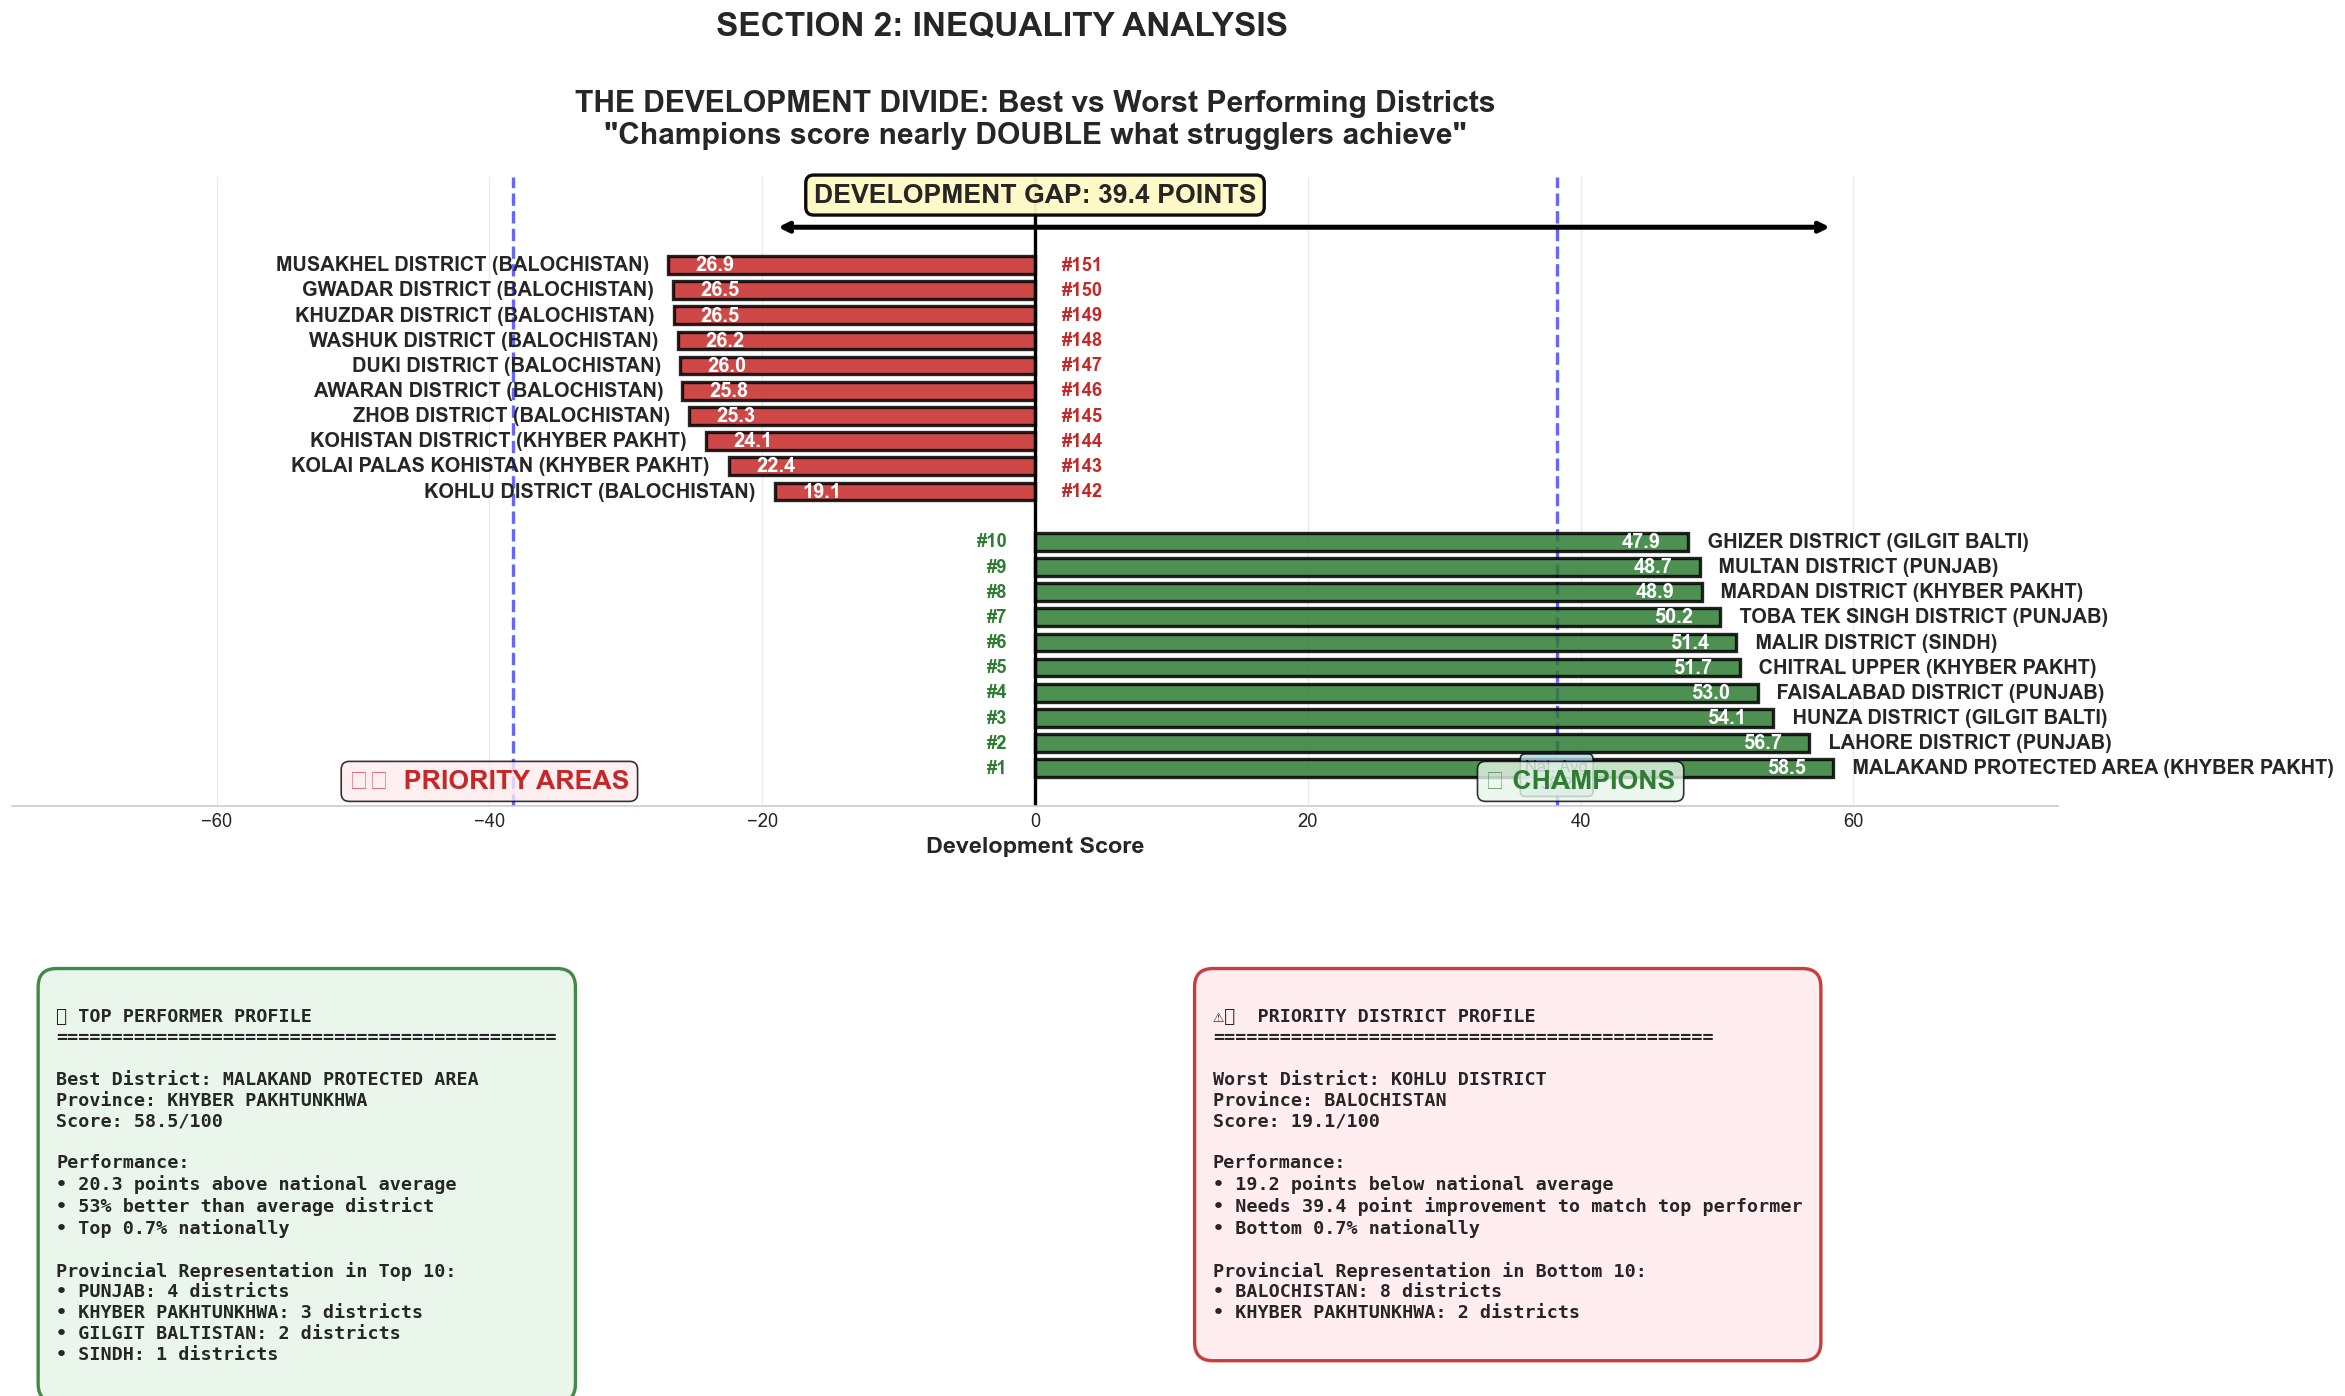


KEY FINDING #2: EXTREME INEQUALITY
Gap between best and worst: 39.4 points
Top district is 3.1x better than bottom district
This gap represents fundamental inequality in citizen access to services.


In [3]:
# Visualization 2: Top 10 vs Bottom 10 Districts
fig = plt.figure(figsize=(22, 12))
gs = GridSpec(2, 2, figure=fig, height_ratios=[2, 1], hspace=0.35, wspace=0.3)

# Main comparison chart
ax_main = fig.add_subplot(gs[0, :])

top_10 = df.nlargest(10, 'Composite_Score')[['Name of District', 'Name of Province', 'Composite_Score']]
bottom_10 = df.nsmallest(10, 'Composite_Score')[['Name of District', 'Name of Province', 'Composite_Score']]

y_pos = np.arange(10)
gap = top_10.iloc[0]['Composite_Score'] - bottom_10.iloc[0]['Composite_Score']

# Plot top 10 (positive side)
bars_top = ax_main.barh(y_pos, top_10['Composite_Score'].values, height=0.7,
                        color='#2e7d32', alpha=0.85, edgecolor='black', linewidth=2,
                        label='TOP 10 DISTRICTS')

# Plot bottom 10 (negative side)
bars_bottom = ax_main.barh(y_pos + 11, -bottom_10['Composite_Score'].values, height=0.7,
                           color='#c62828', alpha=0.85, edgecolor='black', linewidth=2,
                           label='BOTTOM 10 DISTRICTS')

# Add district labels and scores - TOP 10
for i, (idx, row) in enumerate(top_10.iterrows()):
    # District name (outside bar)
    ax_main.text(row['Composite_Score'] + 1, i,
                f" {row['Name of District']} ({row['Name of Province'][:12]})",
                va='center', fontsize=12, fontweight='bold')
    # Score (inside bar)
    ax_main.text(row['Composite_Score'] - 2, i, f"{row['Composite_Score']:.1f}",
                va='center', ha='right', fontsize=12, color='white', fontweight='bold')
    # Rank
    ax_main.text(-2, i, f"#{i+1}", va='center', ha='right', 
                fontsize=11, fontweight='bold', color='#2e7d32')

# Add district labels and scores - BOTTOM 10
for i, (idx, row) in enumerate(bottom_10.iterrows()):
    # District name (outside bar)
    ax_main.text(-row['Composite_Score'] - 1, i + 11,
                f"{row['Name of District']} ({row['Name of Province'][:12]}) ",
                va='center', ha='right', fontsize=12, fontweight='bold')
    # Score (inside bar)
    ax_main.text(-row['Composite_Score'] + 2, i + 11, f"{row['Composite_Score']:.1f}",
                va='center', ha='left', fontsize=12, color='white', fontweight='bold')
    # Rank
    ax_main.text(2, i + 11, f"#{len(df)-9+i}", va='center', ha='left',
                fontsize=11, fontweight='bold', color='#c62828')

# National average lines
nat_avg = df['Composite_Score'].mean()
ax_main.axvline(nat_avg, color='blue', linestyle='--', linewidth=2, alpha=0.6, zorder=0)
ax_main.axvline(-nat_avg, color='blue', linestyle='--', linewidth=2, alpha=0.6, zorder=0)
ax_main.text(nat_avg, -0.8, f'Nat. Avg\n{nat_avg:.1f}', ha='center', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# Gap arrow and label
ax_main.annotate('', xy=(top_10.iloc[0]['Composite_Score'], 21.5),
                xytext=(-bottom_10.iloc[0]['Composite_Score'], 21.5),
                arrowprops=dict(arrowstyle='<->', color='black', lw=3))
ax_main.text(0, 22.5, f'DEVELOPMENT GAP: {gap:.1f} POINTS', ha='center',
            fontsize=16, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='#fff9c4', 
                     edgecolor='black', linewidth=2, alpha=0.95))

# Styling
ax_main.set_ylim(-1.5, 23.5)
ax_main.set_xlim(-75, 75)
ax_main.axvline(0, color='black', linewidth=2)
ax_main.set_yticks([])
ax_main.set_xlabel('Development Score', fontsize=14, fontweight='bold')
ax_main.set_title('THE DEVELOPMENT DIVIDE: Best vs Worst Performing Districts\n"Champions score nearly DOUBLE what strugglers achieve"',
                 fontsize=18, fontweight='bold', pad=20)
ax_main.spines['left'].set_visible(False)
ax_main.spines['right'].set_visible(False)
ax_main.spines['top'].set_visible(False)
ax_main.grid(axis='x', alpha=0.4)

# Section labels
ax_main.text(40, -0.8, '🏆 CHAMPIONS', fontsize=16, fontweight='bold',
            color='#2e7d32', ha='center',
            bbox=dict(boxstyle='round', facecolor='#e8f5e9', alpha=0.8))
ax_main.text(-40, -0.8, '⚠️  PRIORITY AREAS', fontsize=16, fontweight='bold',
            color='#c62828', ha='center',
            bbox=dict(boxstyle='round', facecolor='#ffebee', alpha=0.8))

# Bottom left: Champion profile
ax_champ = fig.add_subplot(gs[1, 0])
ax_champ.axis('off')

champ_text = f"""
🏆 TOP PERFORMER PROFILE
{'='*45}

Best District: {top_10.iloc[0]['Name of District']}
Province: {top_10.iloc[0]['Name of Province']}
Score: {top_10.iloc[0]['Composite_Score']:.1f}/100

Performance:
• {top_10.iloc[0]['Composite_Score'] - nat_avg:.1f} points above national average
• {((top_10.iloc[0]['Composite_Score'] / nat_avg) - 1) * 100:.0f}% better than average district
• Top {(1/len(df))*100:.1f}% nationally

Provincial Representation in Top 10:
"""

top_prov_counts = top_10['Name of Province'].value_counts()
for prov, count in top_prov_counts.items():
    champ_text += f"• {prov}: {count} districts\n"

ax_champ.text(0.05, 0.95, champ_text, fontsize=11, verticalalignment='top',
             family='monospace', fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='#e8f5e9', 
                      edgecolor='#2e7d32', linewidth=2, alpha=0.9, pad=1))

# Bottom right: Struggler profile
ax_strug = fig.add_subplot(gs[1, 1])
ax_strug.axis('off')

strug_text = f"""
⚠️  PRIORITY DISTRICT PROFILE
{'='*45}

Worst District: {bottom_10.iloc[0]['Name of District']}
Province: {bottom_10.iloc[0]['Name of Province']}
Score: {bottom_10.iloc[0]['Composite_Score']:.1f}/100

Performance:
• {nat_avg - bottom_10.iloc[0]['Composite_Score']:.1f} points below national average
• Needs {gap:.1f} point improvement to match top performer
• Bottom {(1/len(df))*100:.1f}% nationally

Provincial Representation in Bottom 10:
"""

bottom_prov_counts = bottom_10['Name of Province'].value_counts()
for prov, count in bottom_prov_counts.items():
    strug_text += f"• {prov}: {count} districts\n"

ax_strug.text(0.05, 0.95, strug_text, fontsize=11, verticalalignment='top',
             family='monospace', fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='#ffebee',
                      edgecolor='#c62828', linewidth=2, alpha=0.9, pad=1))

plt.suptitle('SECTION 2: INEQUALITY ANALYSIS', fontsize=20, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("KEY FINDING #2: EXTREME INEQUALITY")
print("="*70)
print(f"Gap between best and worst: {gap:.1f} points")
print(f"Top district is {(top_10.iloc[0]['Composite_Score'] / bottom_10.iloc[0]['Composite_Score']):.1f}x better than bottom district")
print(f"This gap represents fundamental inequality in citizen access to services.")
print("="*70)

### 💡 WHAT THIS MEANS FOR POLICY

**The Challenge**: Pakistan has two distinct development realities. Citizens in top districts experience quality of life nearly double that of bottom districts.

**Why It Matters**:
- **Social Cohesion**: Such extreme inequality threatens national unity
- **Migration Pressure**: Citizens move from underdeveloped to developed districts
- **Political Stability**: Areas feeling "left behind" create governance challenges
- **Economic Efficiency**: Cannot maximize national potential with such disparities

**Success Stories**: The top 10 prove that high development IS achievable in Pakistan's context. These districts provide models that can be studied and replicated.

### 📋 POLICY RECOMMENDATIONS

1. **Study Success Factors**
   - Commission detailed case studies of top 10 districts
   - Identify replicable policies and practices
   - Create "twinning" programs: pair each bottom-10 district with a top performer

2. **Targeted Intervention for Bottom 10**
   - Declare these districts "Special Development Zones"
   - Assign dedicated federal development officers
   - Fast-track PKR 50 billion emergency fund allocation
   - Set 5-year target: bring all above score of 35

3. **Reduce Inequality**
   - Set maximum acceptable gap: 25 points (currently 39)
   - Progressive resource allocation: more funds to lower-performing districts
   - Annual "State of District Development" report to Parliament
   - Hold provincial governments accountable for reducing within-province gaps

---

---

# Section 3: Provincial Performance

## THE SITUATION: How Do Provinces Compare?

Provincial governments are responsible for development implementation. Understanding provincial performance helps allocate federal resources and hold provinces accountable.

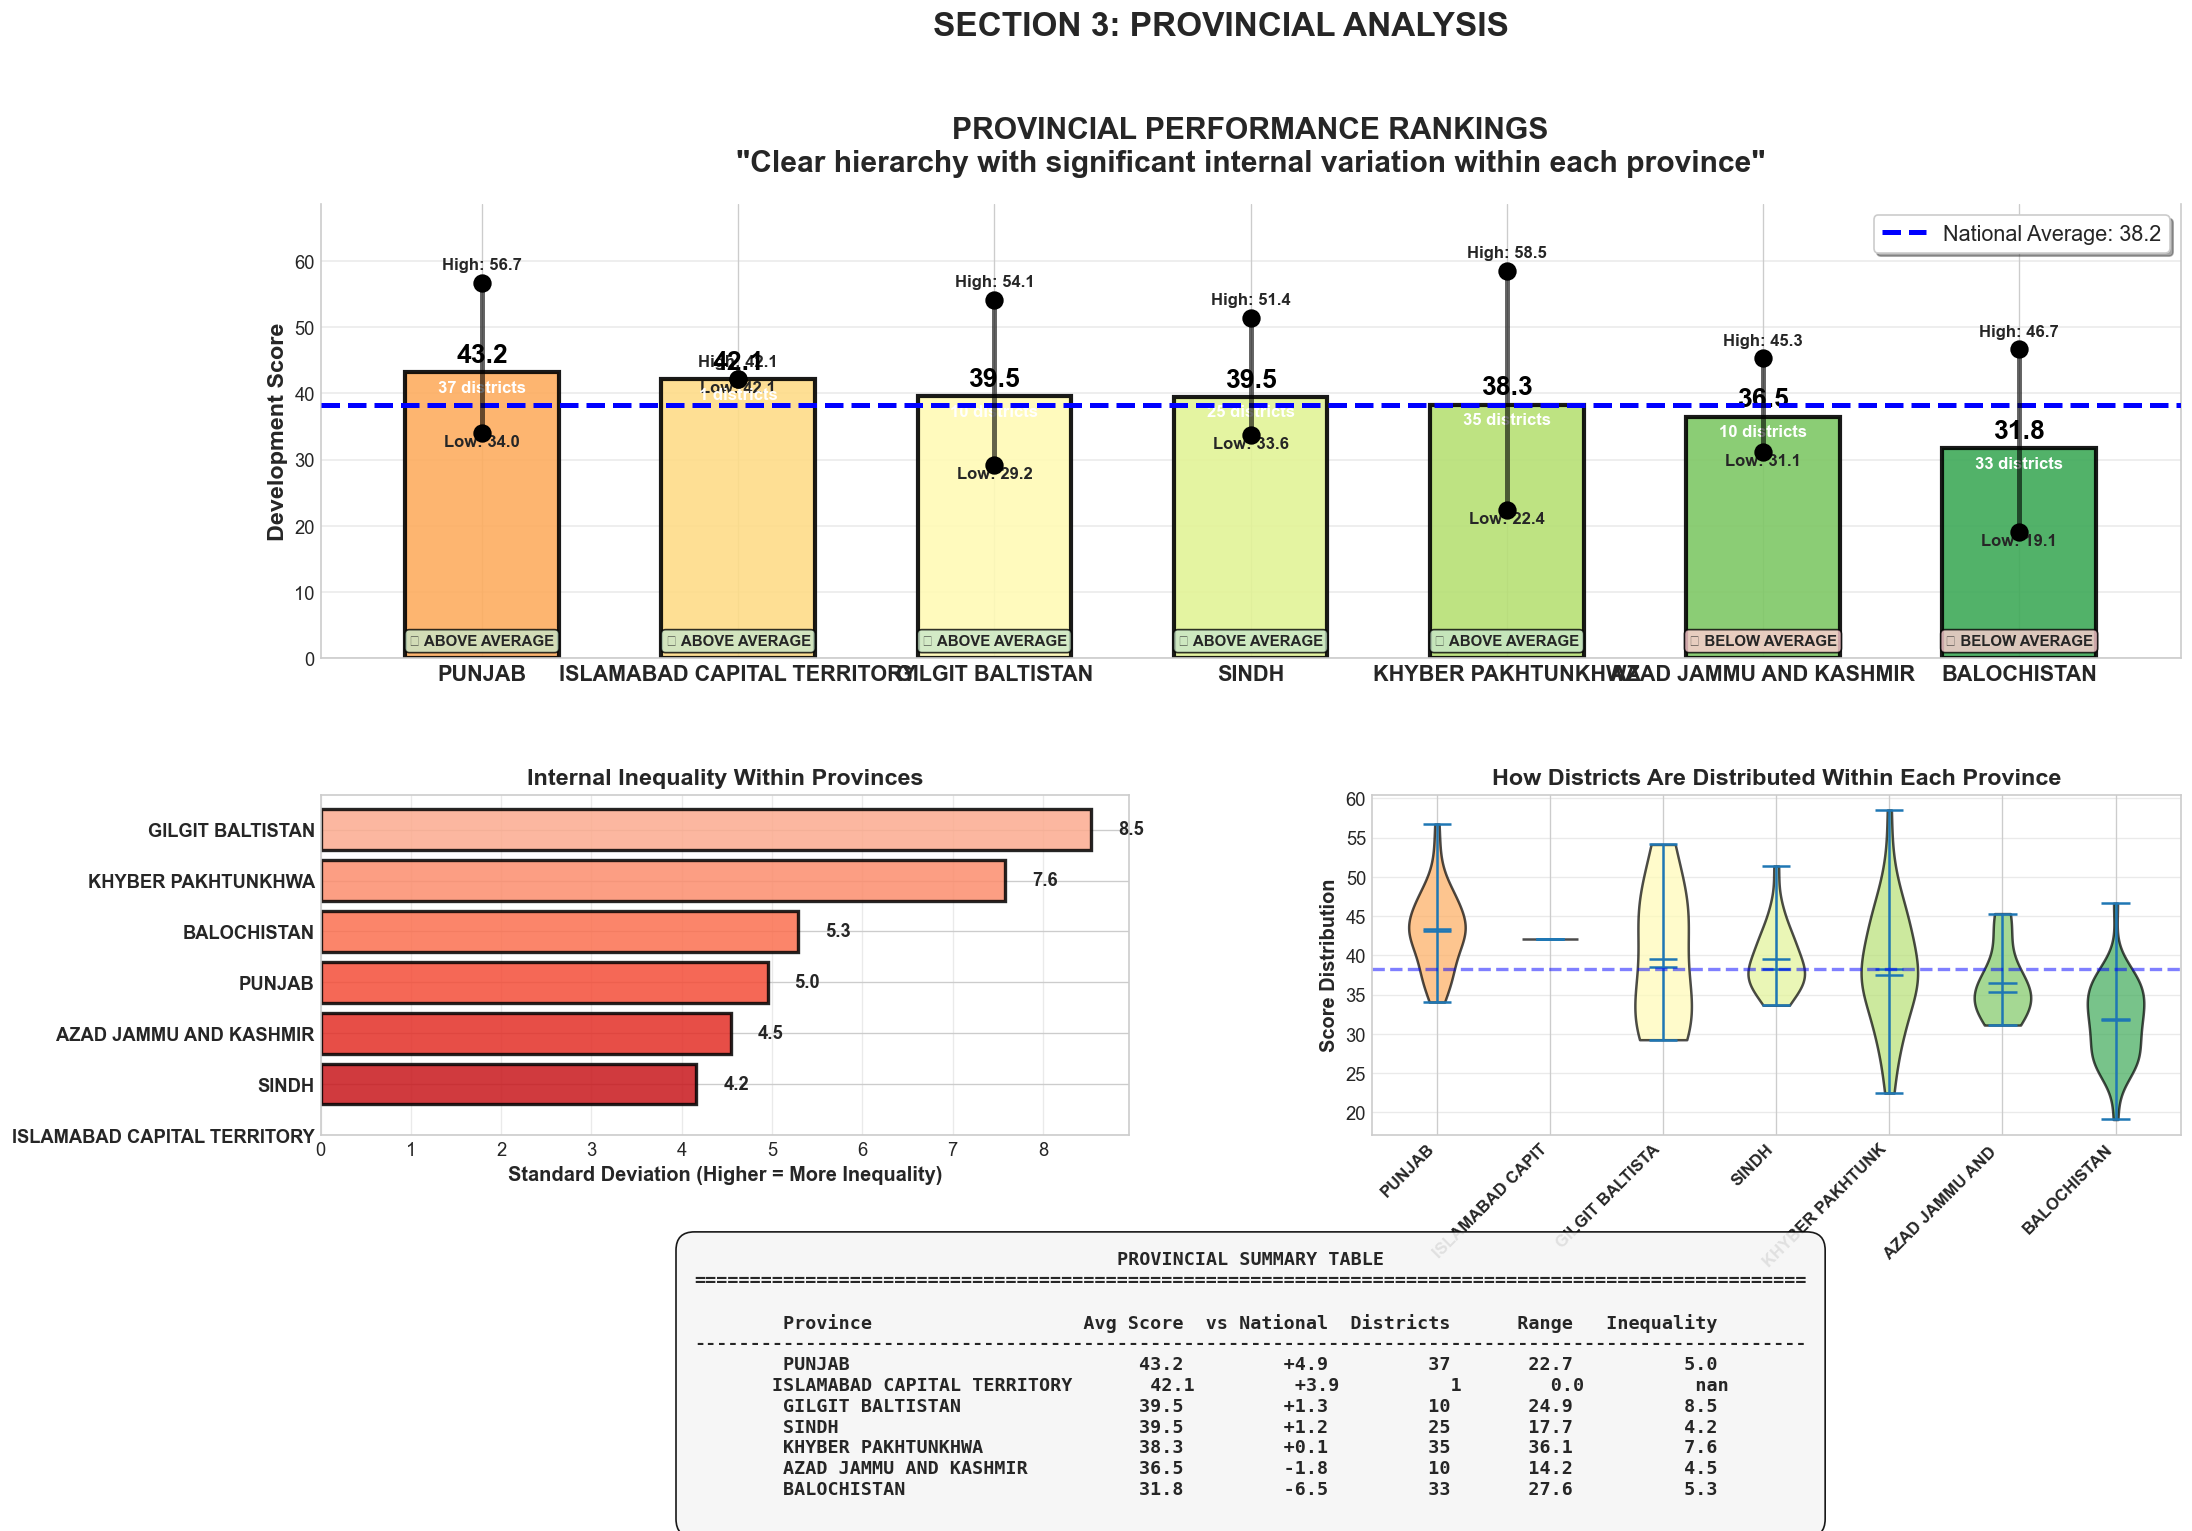


KEY FINDING #3: PROVINCIAL VARIATION
Best province average: 43.2
Worst province average: 31.8
Provincial gap: 11.4 points

Significant internal variation exists within all provinces.


In [4]:
# Visualization 3: Provincial Comparison
fig = plt.figure(figsize=(20, 14))
gs = GridSpec(3, 2, figure=fig, height_ratios=[2, 1.5, 1], hspace=0.4, wspace=0.3)

# Calculate provincial statistics
province_stats = df.groupby('Name of Province').agg({
    'Composite_Score': ['mean', 'std', 'min', 'max', 'count']
}).round(2)
province_stats.columns = ['Mean', 'Std', 'Min', 'Max', 'Count']
province_stats = province_stats.sort_values('Mean', ascending=False)
province_stats['Range'] = province_stats['Max'] - province_stats['Min']

# Main chart: Provincial averages with ranges
ax_main = fig.add_subplot(gs[0, :])

provinces = province_stats.index
x_pos = np.arange(len(provinces))

# Color gradient based on performance
colors_grad = plt.cm.RdYlGn(np.linspace(0.3, 0.85, len(provinces)))

# Plot bars
bars = ax_main.bar(x_pos, province_stats['Mean'], width=0.6,
                   color=colors_grad, edgecolor='black', linewidth=2.5, alpha=0.9)

# Add range indicators
for i, (idx, row) in enumerate(province_stats.iterrows()):
    # Vertical line showing range
    ax_main.plot([i, i], [row['Min'], row['Max']], 'k-', linewidth=3, alpha=0.6, zorder=10)
    ax_main.plot(i, row['Max'], 'ko', markersize=10, zorder=11)
    ax_main.plot(i, row['Min'], 'ko', markersize=10, zorder=11)
    
    # Labels
    ax_main.text(i, row['Max'] + 2, f"High: {row['Max']:.1f}",
                ha='center', fontsize=10, fontweight='bold')
    ax_main.text(i, row['Min'] - 2, f"Low: {row['Min']:.1f}",
                ha='center', fontsize=10, fontweight='bold')
    
    # Average score on bar
    ax_main.text(i, row['Mean'] + 1.5, f"{row['Mean']:.1f}",
                ha='center', fontsize=16, fontweight='bold', color='black')
    
    # District count
    ax_main.text(i, row['Mean'] - 3, f"{int(row['Count'])} districts",
                ha='center', fontsize=10, fontweight='bold', color='white')

# National average
nat_avg = df['Composite_Score'].mean()
ax_main.axhline(nat_avg, color='blue', linestyle='--', linewidth=3,
               label=f'National Average: {nat_avg:.1f}', zorder=5)

# Styling
ax_main.set_xticks(x_pos)
ax_main.set_xticklabels(provinces, fontsize=13, fontweight='bold')
ax_main.set_ylabel('Development Score', fontsize=14, fontweight='bold')
ax_main.set_title('PROVINCIAL PERFORMANCE RANKINGS\n"Clear hierarchy with significant internal variation within each province"',
                 fontsize=18, fontweight='bold', pad=20)
ax_main.legend(fontsize=13, loc='upper right', frameon=True, shadow=True)
ax_main.grid(axis='y', alpha=0.4, linewidth=1)
ax_main.set_ylim(0, province_stats['Max'].max() + 10)
ax_main.spines['top'].set_visible(False)

# Add performance tier labels
for i, (idx, row) in enumerate(province_stats.iterrows()):
    if row['Mean'] >= nat_avg:
        tier_label = '✓ ABOVE AVERAGE'
        tier_color = '#c8e6c9'
    else:
        tier_label = '⚠ BELOW AVERAGE'
        tier_color = '#ffcdd2'
    
    ax_main.text(i, 2, tier_label, ha='center', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor=tier_color, alpha=0.8))

# Middle left: Internal inequality
ax_ineq = fig.add_subplot(gs[1, 0])

colors_ineq = plt.cm.Reds(np.linspace(0.3, 0.85, len(province_stats)))
province_stats_sorted_std = province_stats.sort_values('Std', ascending=False)

bars_ineq = ax_ineq.barh(range(len(province_stats_sorted_std)), 
                         province_stats_sorted_std['Std'],
                         color=colors_ineq, edgecolor='black', linewidth=2, alpha=0.85)

ax_ineq.set_yticks(range(len(province_stats_sorted_std)))
ax_ineq.set_yticklabels(province_stats_sorted_std.index, fontsize=11, fontweight='bold')
ax_ineq.set_xlabel('Standard Deviation (Higher = More Inequality)', 
                   fontsize=12, fontweight='bold')
ax_ineq.set_title('Internal Inequality Within Provinces',
                 fontsize=14, fontweight='bold')
ax_ineq.invert_yaxis()
ax_ineq.grid(axis='x', alpha=0.4)

# Add values
for i, (idx, row) in enumerate(province_stats_sorted_std.iterrows()):
    ax_ineq.text(row['Std'] + 0.3, i, f"{row['Std']:.1f}",
                va='center', fontsize=11, fontweight='bold')

# Middle right: Distribution comparison
ax_dist = fig.add_subplot(gs[1, 1])

province_data = [df[df['Name of Province'] == prov]['Composite_Score'].values
                 for prov in provinces]

violin_parts = ax_dist.violinplot(province_data, positions=range(len(provinces)),
                                   showmeans=True, showmedians=True, showextrema=True)

# Color violins
for pc, color in zip(violin_parts['bodies'], colors_grad):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
    pc.set_edgecolor('black')
    pc.set_linewidth(1.5)

ax_dist.set_xticks(range(len(provinces)))
ax_dist.set_xticklabels([p[:15] for p in provinces], 
                        rotation=45, ha='right', fontsize=10, fontweight='bold')
ax_dist.set_ylabel('Score Distribution', fontsize=12, fontweight='bold')
ax_dist.set_title('How Districts Are Distributed Within Each Province',
                 fontsize=14, fontweight='bold')
ax_dist.axhline(nat_avg, color='blue', linestyle='--', linewidth=2, alpha=0.5)
ax_dist.grid(axis='y', alpha=0.4)

# Bottom: Provincial summary table
ax_table = fig.add_subplot(gs[2, :])
ax_table.axis('off')

table_text = "PROVINCIAL SUMMARY TABLE\n" + "="*100 + "\n\n"
table_text += f"{'Province':<25} {'Avg Score':>10} {'vs National':>12} {'Districts':>10} {'Range':>10} {'Inequality':>12}\n"
table_text += "-"*100 + "\n"

for idx, row in province_stats.iterrows():
    vs_nat = row['Mean'] - nat_avg
    vs_nat_str = f"+{vs_nat:.1f}" if vs_nat >= 0 else f"{vs_nat:.1f}"
    table_text += f"{idx:<25} {row['Mean']:>10.1f} {vs_nat_str:>12} {int(row['Count']):>10} "
    table_text += f"{row['Range']:>10.1f} {row['Std']:>12.1f}\n"

ax_table.text(0.5, 0.5, table_text, fontsize=11, ha='center', va='center',
             family='monospace', fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='#f5f5f5', alpha=0.9, pad=1))

plt.suptitle('SECTION 3: PROVINCIAL ANALYSIS', fontsize=20, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("KEY FINDING #3: PROVINCIAL VARIATION")
print("="*70)
print(f"Best province average: {province_stats.iloc[0]['Mean']:.1f}")
print(f"Worst province average: {province_stats.iloc[-1]['Mean']:.1f}")
print(f"Provincial gap: {province_stats.iloc[0]['Mean'] - province_stats.iloc[-1]['Mean']:.1f} points")
print(f"\nSignificant internal variation exists within all provinces.")
print("="*70)

### 💡 WHAT THIS MEANS FOR POLICY

**The Challenge**: Both inter-provincial (between provinces) and intra-provincial (within provinces) inequality exist.

**Why It Matters**:
- **Federalism**: Provinces have different capacities and challenges
- **Resource Allocation**: NFC awards may not reflect development needs
- **Provincial Accountability**: Some provinces manage better despite similar resources
- **Local Variation**: Even weak provinces have some strong districts (and vice versa)

**Key Insight**: The wide ranges within provinces (shown by vertical lines) indicate that provincial averages mask significant local variation. Some districts in "weak" provinces outperform districts in "strong" provinces.

### 📋 POLICY RECOMMENDATIONS

1. **Federal-Provincial Coordination**
   - Create Federal-Provincial Development Council
   - Link federal funding to development improvement rates
   - Share best practices across provinces
   - Below-average provinces get technical assistance packages

2. **Provincial Accountability**
   - Require annual provincial development reports
   - Set province-specific improvement targets
   - Reward provinces that reduce internal inequality
   - Investigate why some provinces with similar resources perform better

3. **Within-Province Action**
   - Provinces must address their worst-performing districts
   - No province should have districts scoring below 30
   - Create provincial equalization funds
   - Study high-performing districts in low-performing provinces

4. **Adjust Federal Support**
   - Consider development-weighted resource allocation
   - Additional support for provinces with high inequality
   - Performance bonuses for provinces showing improvement

---

---

# Section 4: Development Dimension Breakdown

## THE SITUATION: Which Specific Areas Need Attention?

Pakistan measures development across 11 dimensions. Let's see which areas are strongest nationally and which need the most work.

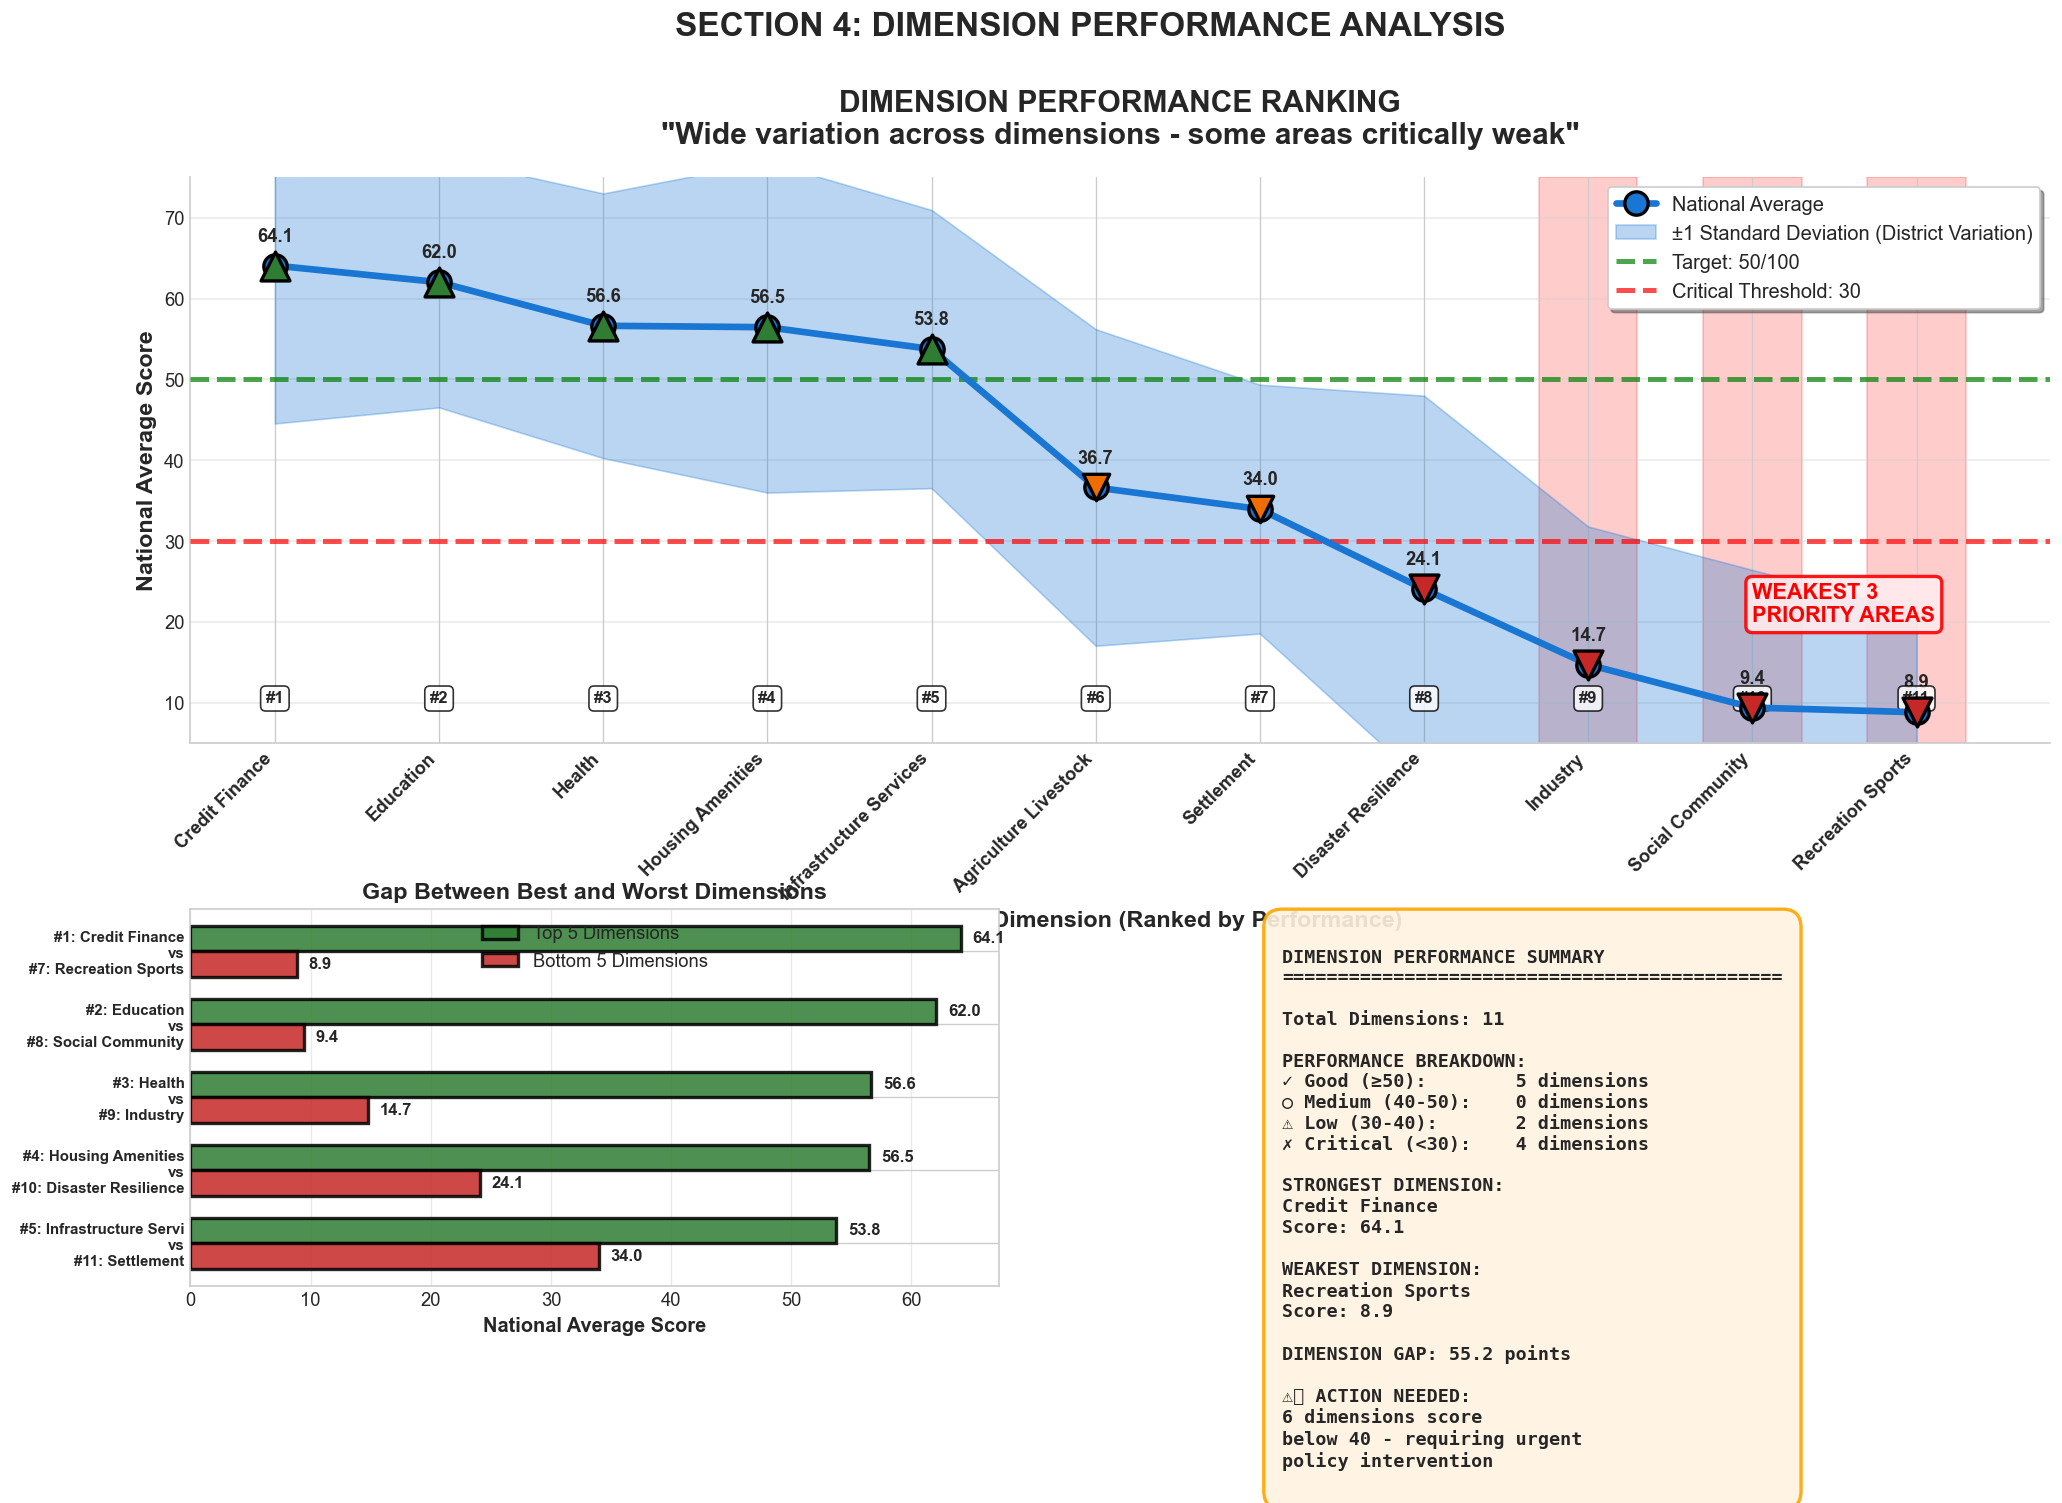


KEY FINDING #4: UNEVEN DIMENSION PERFORMANCE
Best dimension: Credit Finance (64.1)
Worst dimension: Recreation Sports (8.9)
Gap: 55.2 points

6 dimensions need urgent attention (scoring below 40)


In [5]:
# Visualization 4A: Line Chart - Dimension Rankings
fig = plt.figure(figsize=(20, 12))
gs = GridSpec(2, 2, figure=fig, height_ratios=[1.5, 1], hspace=0.35, wspace=0.3)

# Calculate national averages for each dimension
dimension_scores = []
for col in index_cols:
    dim_name = col.replace('_Index', '').replace('_', ' ')
    dimension_scores.append({
        'Dimension': dim_name,
        'National_Avg': df[col].mean(),
        'Std_Dev': df[col].std(),
        'Min': df[col].min(),
        'Max': df[col].max(),
        'Original_Col': col
    })

dim_df = pd.DataFrame(dimension_scores).sort_values('National_Avg', ascending=False)

# Main chart: Line chart showing dimension performance
ax_main = fig.add_subplot(gs[0, :])

# Create ranking positions
x_pos = range(len(dim_df))

# Plot line with markers
line = ax_main.plot(x_pos, dim_df['National_Avg'], 'o-', 
                    linewidth=4, markersize=14, color='#1976d2',
                    markerfacecolor='#1976d2', markeredgecolor='black',
                    markeredgewidth=2, label='National Average', zorder=10)

# Add confidence bands (±1 std dev)
ax_main.fill_between(x_pos, 
                      dim_df['National_Avg'] - dim_df['Std_Dev'],
                      dim_df['National_Avg'] + dim_df['Std_Dev'],
                      alpha=0.3, color='#1976d2', 
                      label='±1 Standard Deviation (District Variation)')

# Add target line at 50
ax_main.axhline(50, color='green', linestyle='--', linewidth=3, 
                alpha=0.7, label='Target: 50/100', zorder=5)

# Add critical threshold at 30
ax_main.axhline(30, color='red', linestyle='--', linewidth=3,
                alpha=0.7, label='Critical Threshold: 30', zorder=5)

# Color-code points based on performance
for i, (idx, row) in enumerate(dim_df.iterrows()):
    if row['National_Avg'] >= 50:
        color = '#2e7d32'  # Green - Good
        marker = '^'
        size = 300
    elif row['National_Avg'] >= 40:
        color = '#fbc02d'  # Yellow - Medium
        marker = 'o'
        size = 250
    elif row['National_Avg'] >= 30:
        color = '#ef6c00'  # Orange - Low
        marker = 'v'
        size = 250
    else:
        color = '#c62828'  # Red - Critical
        marker = 'v'
        size = 300
    
    ax_main.scatter(i, row['National_Avg'], s=size, c=color, 
                   marker=marker, edgecolor='black', linewidth=2, zorder=11)

# Add value labels
for i, (idx, row) in enumerate(dim_df.iterrows()):
    # Score above point
    ax_main.text(i, row['National_Avg'] + 3, f"{row['National_Avg']:.1f}",
                ha='center', fontsize=11, fontweight='bold')
    
    # Rank below
    ax_main.text(i, 10, f"#{i+1}",
                ha='center', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Styling
ax_main.set_xticks(x_pos)
ax_main.set_xticklabels(dim_df['Dimension'], rotation=45, ha='right', 
                        fontsize=11, fontweight='bold')
ax_main.set_ylabel('National Average Score', fontsize=14, fontweight='bold')
ax_main.set_xlabel('Development Dimension (Ranked by Performance)', 
                   fontsize=14, fontweight='bold')
ax_main.set_title('DIMENSION PERFORMANCE RANKING\n"Wide variation across dimensions - some areas critically weak"',
                 fontsize=18, fontweight='bold', pad=20)
ax_main.legend(fontsize=12, loc='upper right', frameon=True, shadow=True)
ax_main.grid(axis='y', alpha=0.4, linewidth=1)
ax_main.set_ylim(5, 75)
ax_main.spines['top'].set_visible(False)
ax_main.spines['right'].set_visible(False)

# Highlight weakest 3
weakest_3 = dim_df.nsmallest(3, 'National_Avg')
for i, (idx, row) in enumerate(weakest_3.iterrows()):
    rank = dim_df.index.get_loc(idx)
    ax_main.axvspan(rank - 0.3, rank + 0.3, alpha=0.2, color='red', zorder=0)

ax_main.text(len(dim_df) - 2, 20, 'WEAKEST 3\nPRIORITY AREAS',
            fontsize=13, fontweight='bold', color='red',
            bbox=dict(boxstyle='round', facecolor='#ffebee', 
                     edgecolor='red', linewidth=2, alpha=0.9))

# Bottom left: Top 5 and Bottom 5 comparison
ax_compare = fig.add_subplot(gs[1, 0])

top_5_dims = dim_df.head(5)
bottom_5_dims = dim_df.tail(5)

y_pos_compare = np.arange(5)
width = 0.35

# Plot both
bars1 = ax_compare.barh(y_pos_compare - width/2, top_5_dims['National_Avg'].values, 
                        width, label='Top 5 Dimensions',
                        color='#2e7d32', alpha=0.85, edgecolor='black', linewidth=2)
bars2 = ax_compare.barh(y_pos_compare + width/2, bottom_5_dims['National_Avg'].values[::-1],
                        width, label='Bottom 5 Dimensions',
                        color='#c62828', alpha=0.85, edgecolor='black', linewidth=2)

# Labels
for i, val in enumerate(top_5_dims['National_Avg'].values):
    ax_compare.text(val + 1, i - width/2, f'{val:.1f}',
                   va='center', fontsize=10, fontweight='bold')

for i, val in enumerate(bottom_5_dims['National_Avg'].values[::-1]):
    ax_compare.text(val + 1, i + width/2, f'{val:.1f}',
                   va='center', fontsize=10, fontweight='bold')

ax_compare.set_yticks(y_pos_compare)
labels_compare = [f"#{i+1}: {top_5_dims.iloc[i]['Dimension'][:20]}\nvs\n#{len(dim_df)-4+i}: {bottom_5_dims.iloc[4-i]['Dimension'][:20]}" 
                  for i in range(5)]
ax_compare.set_yticklabels(labels_compare, fontsize=9, fontweight='bold')
ax_compare.set_xlabel('National Average Score', fontsize=12, fontweight='bold')
ax_compare.set_title('Gap Between Best and Worst Dimensions',
                    fontsize=14, fontweight='bold')
ax_compare.legend(fontsize=11)
ax_compare.grid(axis='x', alpha=0.4)
ax_compare.invert_yaxis()

# Bottom right: Statistics
ax_stats = fig.add_subplot(gs[1, 1])
ax_stats.axis('off')

above_50 = len(dim_df[dim_df['National_Avg'] >= 50])
between_40_50 = len(dim_df[(dim_df['National_Avg'] >= 40) & (dim_df['National_Avg'] < 50)])
between_30_40 = len(dim_df[(dim_df['National_Avg'] >= 30) & (dim_df['National_Avg'] < 40)])
below_30 = len(dim_df[dim_df['National_Avg'] < 30])

stats_text = f"""
DIMENSION PERFORMANCE SUMMARY
{'='*45}

Total Dimensions: {len(dim_df)}

PERFORMANCE BREAKDOWN:
✓ Good (≥50):        {above_50} dimensions
○ Medium (40-50):    {between_40_50} dimensions
⚠ Low (30-40):       {between_30_40} dimensions
✗ Critical (<30):    {below_30} dimensions

STRONGEST DIMENSION:
{dim_df.iloc[0]['Dimension']}
Score: {dim_df.iloc[0]['National_Avg']:.1f}

WEAKEST DIMENSION:
{dim_df.iloc[-1]['Dimension']}
Score: {dim_df.iloc[-1]['National_Avg']:.1f}

DIMENSION GAP: {dim_df.iloc[0]['National_Avg'] - dim_df.iloc[-1]['National_Avg']:.1f} points

⚠️ ACTION NEEDED:
{below_30 + between_30_40} dimensions score
below 40 - requiring urgent
policy intervention
"""

ax_stats.text(0.05, 0.95, stats_text, fontsize=11, verticalalignment='top',
             family='monospace', fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='#fff3e0',
                      edgecolor='orange', linewidth=2, alpha=0.9, pad=1))

plt.suptitle('SECTION 4: DIMENSION PERFORMANCE ANALYSIS', 
             fontsize=20, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("KEY FINDING #4: UNEVEN DIMENSION PERFORMANCE")
print("="*70)
print(f"Best dimension: {dim_df.iloc[0]['Dimension']} ({dim_df.iloc[0]['National_Avg']:.1f})")
print(f"Worst dimension: {dim_df.iloc[-1]['Dimension']} ({dim_df.iloc[-1]['National_Avg']:.1f})")
print(f"Gap: {dim_df.iloc[0]['National_Avg'] - dim_df.iloc[-1]['National_Avg']:.1f} points")
print(f"\n{below_30 + between_30_40} dimensions need urgent attention (scoring below 40)")
print("="*70)

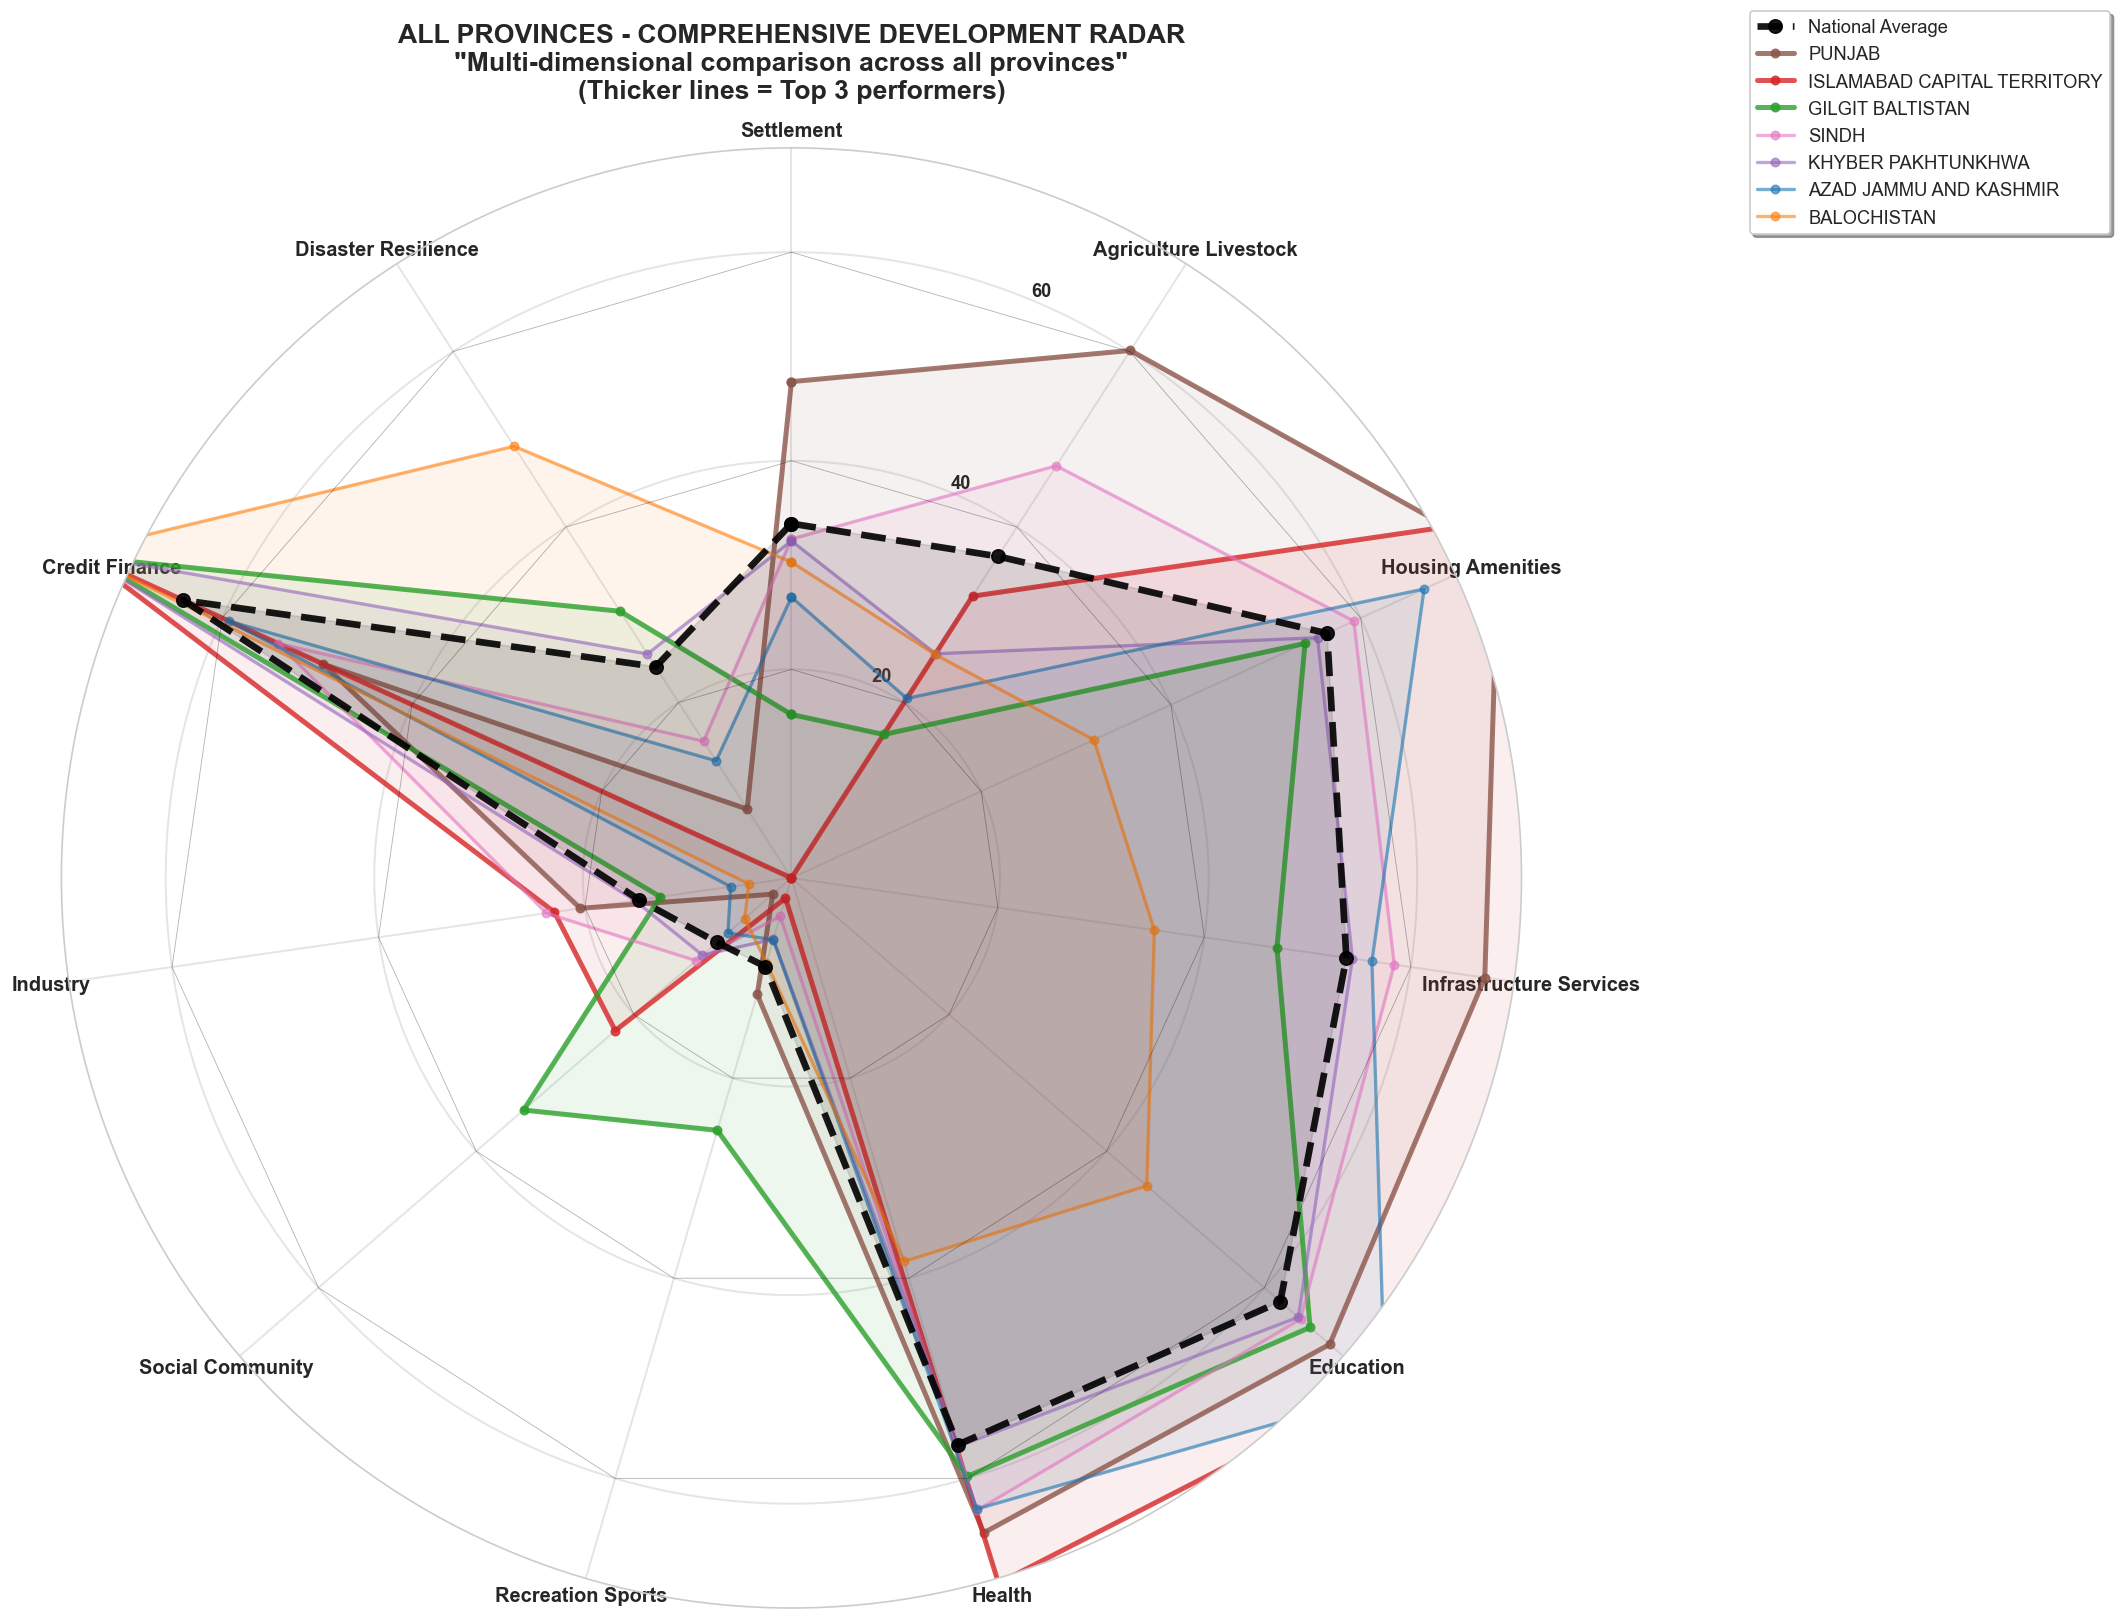


COMPREHENSIVE RADAR CHART ANALYSIS

Provincial Development Balance (Lower = More Balanced):
  PUNJAB: 27.29 ⚠ Unbalanced
  ISLAMABAD CAPITAL TERRITORY: 34.89 ⚠ Unbalanced
  GILGIT BALTISTAN: 21.69 ⚠ Unbalanced
  SINDH: 22.58 ⚠ Unbalanced
  KHYBER PAKHTUNKHWA: 23.54 ⚠ Unbalanced
  AZAD JAMMU AND KASHMIR: 27.53 ⚠ Unbalanced
  BALOCHISTAN: 21.08 ⚠ Unbalanced

Each Province's Strongest Dimension:
  PUNJAB: Housing Amenities (74.5)
  ISLAMABAD CAPITAL TERRITORY: Housing Amenities (86.7)
  GILGIT BALTISTAN: Credit Finance (74.0)
  SINDH: Education (64.6)
  KHYBER PAKHTUNKHWA: Credit Finance (74.5)
  AZAD JAMMU AND KASHMIR: Education (75.3)
  BALOCHISTAN: Credit Finance (75.3)

Each Province's Weakest Dimension:
  PUNJAB: Social Community (2.4)
  ISLAMABAD CAPITAL TERRITORY: Settlement (0.0)
  GILGIT BALTISTAN: Industry (12.7)
  SINDH: Recreation Sports (3.8)
  KHYBER PAKHTUNKHWA: Recreation Sports (6.1)
  AZAD JAMMU AND KASHMIR: Industry (5.9)
  BALOCHISTAN: Industry (4.1)

Dimensions Above

In [6]:
# Visualization 4B: Radar Chart - All Provincial Development Profiles
fig, ax = plt.subplots(figsize=(18, 18), subplot_kw=dict(projection='polar'))

# Get all provinces sorted by performance
province_avg_scores = df.groupby('Name of Province')['Composite_Score'].mean().sort_values(ascending=False)
all_provinces = province_avg_scores.index.tolist()
national_label = 'National Average'

# Calculate average scores per dimension
dimension_names = [col.replace('_Index', '').replace('_', ' ') for col in index_cols]
num_vars = len(index_cols)

# Compute angle for each axis
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Complete the circle

# Plot national average first (as reference)
nat_values = df[index_cols].mean().values.tolist()
nat_values += nat_values[:1]
ax.plot(angles, nat_values, 'o-', linewidth=4, label=national_label,
       color='black', linestyle='--', alpha=0.9, markersize=8, zorder=100)
ax.fill(angles, nat_values, alpha=0.1, color='black', zorder=99)

# Plot each province
for i, prov in enumerate(all_provinces):
    prov_data = df[df['Name of Province'] == prov]
    values = prov_data[index_cols].mean().values.tolist()
    values += values[:1]  # Complete the circle
    
    color = PROVINCE_COLORS[prov]
    
    # Vary line styles for better distinction
    if i < 3:  # Top 3 - solid, thicker lines
        linewidth = 3
        linestyle = '-'
        alpha = 0.8
    else:  # Others - thinner lines
        linewidth = 2
        linestyle = '-'
        alpha = 0.6
    
    ax.plot(angles, values, 'o-', linewidth=linewidth, label=prov,
           color=color, linestyle=linestyle, alpha=alpha, markersize=5)
    ax.fill(angles, values, alpha=0.08, color=color)

# Fix axis to go in the right order and start at 12 o'clock
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# Draw axis lines for each angle and label
ax.set_xticks(angles[:-1])
ax.set_xticklabels(dimension_names, fontsize=12, fontweight='bold')

# Set y-axis limits and labels
ax.set_ylim(0, 70)
ax.set_yticks([20, 40, 60])
ax.set_yticklabels(['20', '40', '60'], fontsize=11, fontweight='bold')

# Add concentric circles for reference
for val in [20, 40, 60]:
    ax.plot(angles, [val] * len(angles), 'k-', linewidth=0.5, alpha=0.3)

# Title
ax.set_title('ALL PROVINCES - COMPREHENSIVE DEVELOPMENT RADAR\n"Multi-dimensional comparison across all provinces"\n(Thicker lines = Top 3 performers)',
            fontsize=16, fontweight='bold', pad=30)

# Legend - positioned outside the plot
ax.legend(loc='upper left', bbox_to_anchor=(1.15, 1.1), fontsize=11, 
         frameon=True, shadow=True, ncol=1)

# Grid styling
ax.grid(True, linewidth=1.2, alpha=0.5)

plt.tight_layout()
plt.show()

# Analysis output
print("\n" + "="*70)
print("COMPREHENSIVE RADAR CHART ANALYSIS")
print("="*70)

# Calculate balance score (standard deviation - lower is more balanced)
print("\nProvincial Development Balance (Lower = More Balanced):")
balance_scores = {}
for prov in all_provinces:
    prov_data = df[df['Name of Province'] == prov]
    dim_scores = prov_data[index_cols].mean()
    balance_score = dim_scores.std()
    balance_scores[prov] = balance_score
    balance_status = "✓ Balanced" if balance_score < 10 else "⚠ Unbalanced"
    print(f"  {prov}: {balance_score:.2f} {balance_status}")

print("\nEach Province's Strongest Dimension:")
for prov in all_provinces:
    prov_data = df[df['Name of Province'] == prov]
    best_dim = prov_data[index_cols].mean().idxmax()
    best_score = prov_data[index_cols].mean().max()
    print(f"  {prov}: {best_dim.replace('_Index', '').replace('_', ' ')} ({best_score:.1f})")

print("\nEach Province's Weakest Dimension:")
for prov in all_provinces:
    prov_data = df[df['Name of Province'] == prov]
    worst_dim = prov_data[index_cols].mean().idxmin()
    worst_score = prov_data[index_cols].mean().min()
    print(f"  {prov}: {worst_dim.replace('_Index', '').replace('_', ' ')} ({worst_score:.1f})")

print("\nDimensions Above National Average (by Province):")
nat_avg_dims = df[index_cols].mean()
for prov in all_provinces:
    prov_data = df[df['Name of Province'] == prov]
    prov_dims = prov_data[index_cols].mean()
    above_nat = sum(prov_dims > nat_avg_dims)
    print(f"  {prov}: {above_nat}/{len(index_cols)} dimensions above national average")

print("="*70)

### 💡 RADAR CHART INSIGHTS

**What Radar Charts Reveal**:
- **Balanced vs Unbalanced Development**: Circular shapes indicate balanced growth across all dimensions; irregular shapes show uneven development
- **Provincial Strengths**: Each province has specific dimensions where it excels
- **Critical Gaps**: Dramatic indentations reveal areas needing urgent intervention
- **Comparison to National Average**: Shows whether provinces lead or lag in each dimension

**Key Observations**:
- **Top Provinces**: Generally show more circular/balanced profiles, with most dimensions above national average
- **Bottom Provinces**: Display irregular, spiky profiles with several dimensions significantly below average
- **Strategic Implications**: Bottom provinces need multi-dimensional interventions, not just sector-specific fixes

### 📋 POLICY RECOMMENDATIONS FROM RADAR ANALYSIS

1. **Balanced Development Targets**
   - No dimension should fall below 30 in any province
   - Aim for more circular profiles (balanced growth)
   - Identify and address the "deepest indentations" first

2. **Province-Specific Strategies**
   - Top provinces: Maintain strengths, address minor weaknesses
   - Bottom provinces: Focus on 2-3 worst dimensions simultaneously
   - Learn from provinces with strong performance in specific dimensions

3. **Multi-Sectoral Approach**
   - Unbalanced profiles require integrated interventions
   - Cannot fix one dimension while ignoring others
   - Create cross-sector development plans

4. **Benchmarking Against National Average**
   - All provinces should exceed national average in at least 5 dimensions
   - Set provincial targets based on national benchmarks
   - Track progress toward more balanced profiles over time

---

---

# Section 6: Provincial Development Composition

## THE SITUATION: What Are Provinces Investing In?

Let's analyze how development resources are distributed across different dimensions within each province using stacked visualizations.

### 💡 WHAT THIS MEANS FOR POLICY

**The Challenge**: Not all development dimensions have equal impact. Some areas, when improved, lead to greater overall development gains than others.

**Why It Matters**:
- **Resource Efficiency**: Focus limited resources on high-impact areas
- **Quick Wins**: Improvements in key dimensions yield faster results
- **Strategic Planning**: Understand which sectors drive overall progress

**Key Insight**: The analysis shows that certain dimensions (like Education, Health, or Infrastructure) have outsized influence on overall development scores. Improving these "leverage points" creates ripple effects across other areas.

### 📋 POLICY RECOMMENDATIONS

1. **Priority Investment**
   - Allocate 60% of development budget to top 3 high-impact dimensions
   - These areas provide maximum return on investment
   - Set aggressive targets for improvement in these sectors

2. **Cascade Effects**
   - Improvements in top dimensions often boost other areas automatically
   - For example, better education typically improves health, employment, and technology adoption
   - Design integrated programs that target multiple dimensions simultaneously

3. **Provincial Strategies**
   - Provinces weak in high-impact dimensions need urgent support
   - Share best practices from provinces excelling in priority areas
   - Create provincial action plans focused on top 3 dimensions

4. **Monitoring & Evaluation**
   - Track progress in high-impact dimensions monthly
   - Link federal transfers to improvements in priority areas
   - Publish quarterly scorecards showing dimension-specific progress

---

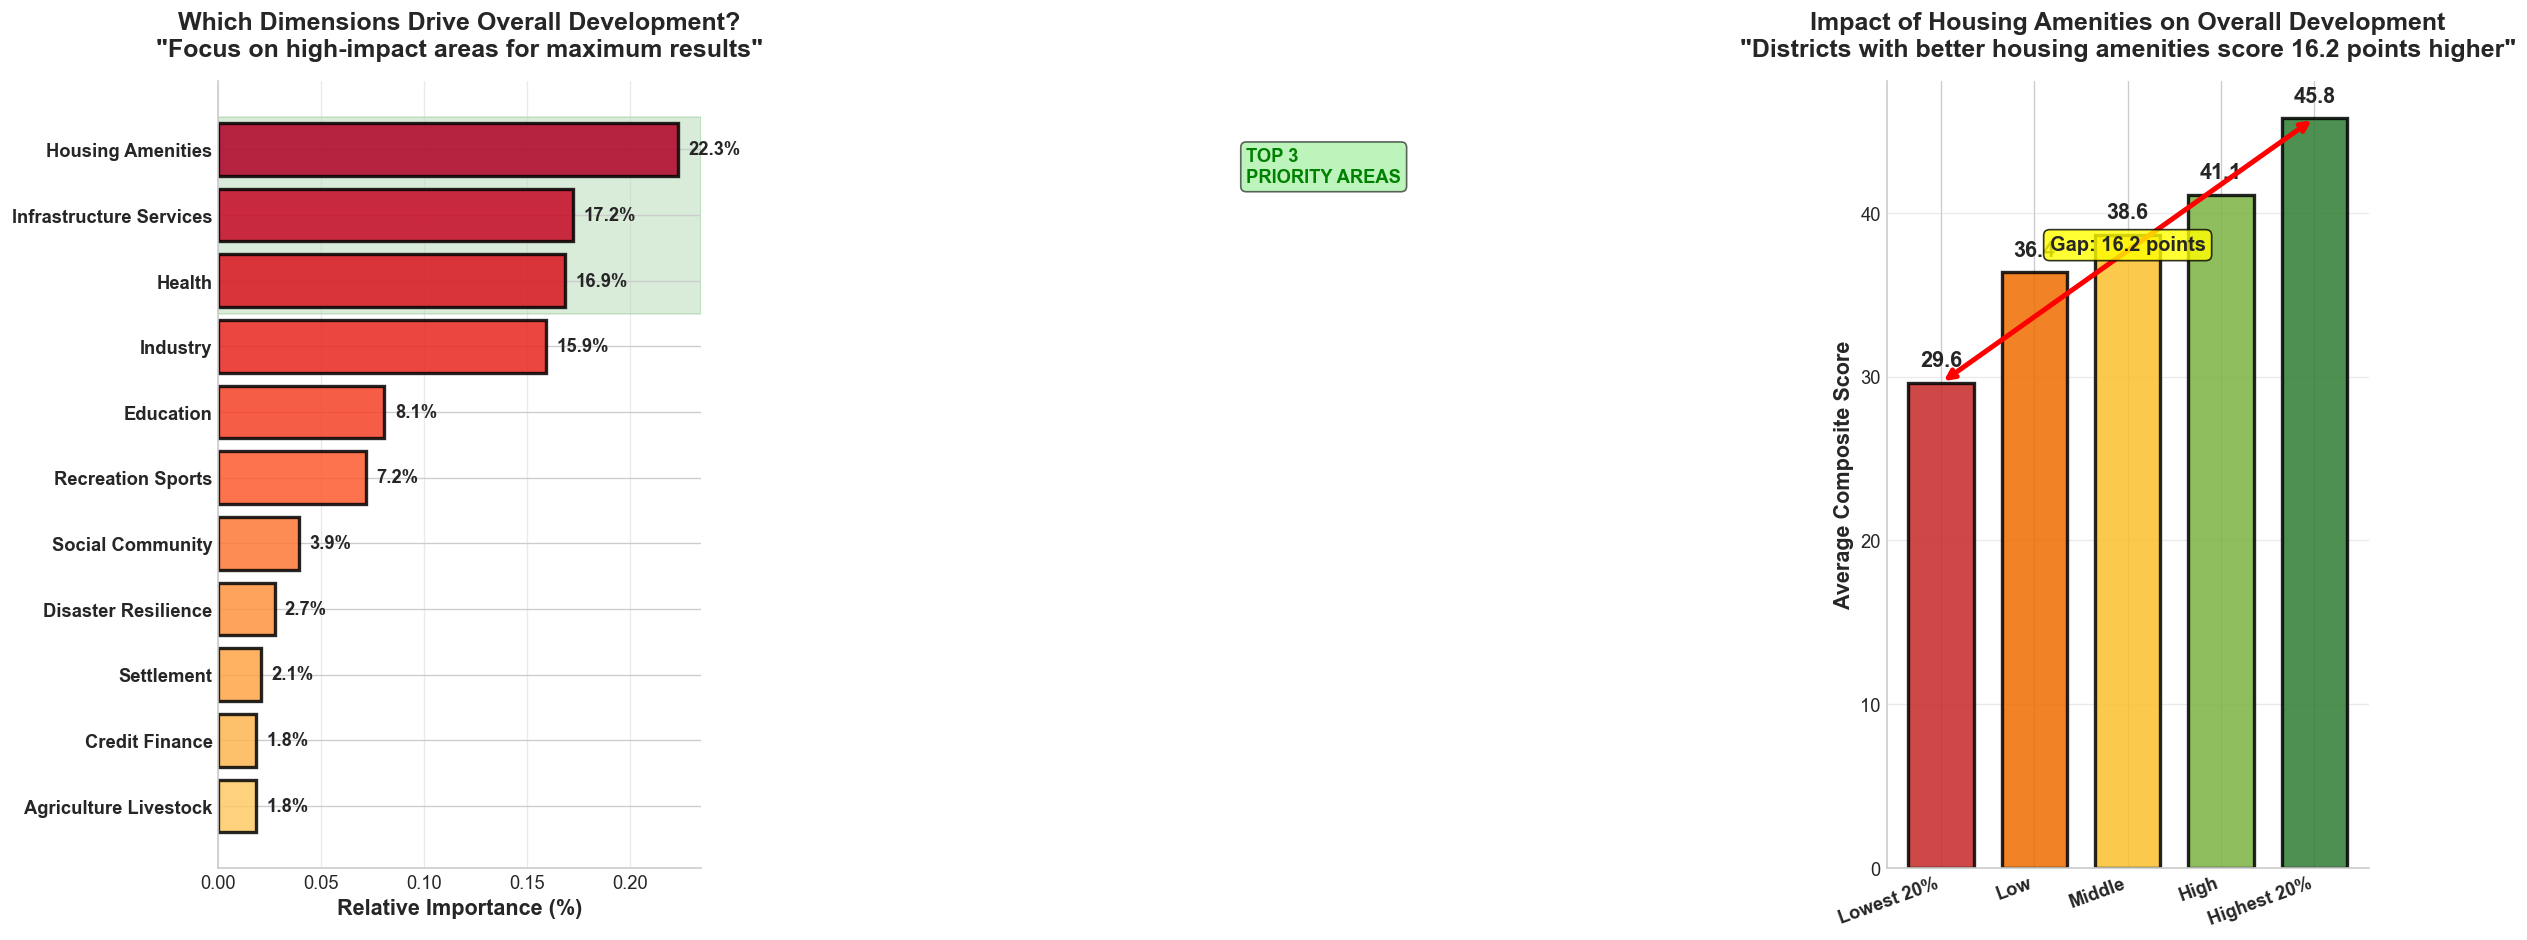


KEY FINDING: DEVELOPMENT DRIVERS
Top 3 most important dimensions:
  1. Housing Amenities: 22.3% importance
  2. Infrastructure Services: 17.2% importance
  3. Health: 16.9% importance

Improving housing amenities from bottom 20% to top 20% associated with 16.2 point increase in overall score


In [7]:
# Visualization 5: Development Drivers Analysis
from sklearn.ensemble import RandomForestRegressor

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Train a model to understand which dimensions drive overall scores
X = df[index_cols]
y = df['Composite_Score']

model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
model.fit(X, y)

# Get feature importance
importance_df = pd.DataFrame({
    'Dimension': [col.replace('_Index', '').replace('_', ' ') for col in index_cols],
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

# Chart 1: Feature importance
colors_importance = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(importance_df)))
bars = ax1.barh(range(len(importance_df)), importance_df['Importance'], 
                color=colors_importance, edgecolor='black', linewidth=2, alpha=0.85)

# Add percentage labels
for i, (idx, row) in enumerate(importance_df.iterrows()):
    pct = row['Importance'] * 100
    ax1.text(row['Importance'] + 0.005, i, f'{pct:.1f}%',
            va='center', fontsize=11, fontweight='bold')

ax1.set_yticks(range(len(importance_df)))
ax1.set_yticklabels(importance_df['Dimension'], fontsize=11, fontweight='bold')
ax1.set_xlabel('Relative Importance (%)', fontsize=13, fontweight='bold')
ax1.set_title('Which Dimensions Drive Overall Development?\n"Focus on high-impact areas for maximum results"',
             fontsize=15, fontweight='bold', pad=15)
ax1.grid(axis='x', alpha=0.4)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Highlight top 3
top_3_start = len(importance_df) - 3
ax1.axhspan(top_3_start - 0.5, len(importance_df) - 0.5, alpha=0.15, color='green', zorder=0)
ax1.text(0.5, len(importance_df) - 1.5, 'TOP 3\nPRIORITY AREAS', 
        fontsize=11, fontweight='bold', color='green',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.6))

# Chart 2: Score comparison by top dimension
top_dimension = importance_df.iloc[-1]['Dimension']
top_dim_col = [col for col in index_cols if top_dimension.replace(' ', '_') in col][0]

# Create quintiles
df['Top_Dim_Quintile'] = pd.qcut(df[top_dim_col], q=5, labels=['Lowest 20%', 'Low', 'Middle', 'High', 'Highest 20%'])

quintile_scores = df.groupby('Top_Dim_Quintile', observed=True)['Composite_Score'].mean()
quintile_colors = ['#c62828', '#ef6c00', '#fbc02d', '#7cb342', '#2e7d32']

bars2 = ax2.bar(range(len(quintile_scores)), quintile_scores, 
               color=quintile_colors, edgecolor='black', linewidth=2, alpha=0.85, width=0.7)

# Add value labels
for i, (bar, val) in enumerate(zip(bars2, quintile_scores)):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}',
            ha='center', fontsize=13, fontweight='bold')

ax2.set_xticks(range(len(quintile_scores)))
ax2.set_xticklabels(quintile_scores.index, fontsize=11, fontweight='bold', rotation=20, ha='right')
ax2.set_ylabel('Average Composite Score', fontsize=13, fontweight='bold')
ax2.set_title(f'Impact of {top_dimension} on Overall Development\n"Districts with better {top_dimension.lower()} score {quintile_scores.iloc[-1] - quintile_scores.iloc[0]:.1f} points higher"',
             fontsize=15, fontweight='bold', pad=15)
ax2.grid(axis='y', alpha=0.4)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Add gap indicator
gap = quintile_scores.iloc[-1] - quintile_scores.iloc[0]
ax2.annotate('', xy=(4, quintile_scores.iloc[-1]), xytext=(0, quintile_scores.iloc[0]),
            arrowprops=dict(arrowstyle='<->', color='red', lw=3))
ax2.text(2, (quintile_scores.iloc[-1] + quintile_scores.iloc[0])/2, 
        f'Gap: {gap:.1f} points', ha='center', fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("KEY FINDING: DEVELOPMENT DRIVERS")
print("="*70)
print(f"Top 3 most important dimensions:")
for i, (idx, row) in enumerate(importance_df.tail(3).iloc[::-1].iterrows(), 1):
    print(f"  {i}. {row['Dimension']}: {row['Importance']*100:.1f}% importance")
print(f"\nImproving {top_dimension.lower()} from bottom 20% to top 20% associated with {gap:.1f} point increase in overall score")
print("="*70)

---

# Section 5: What Drives Development Success?

## THE SITUATION: Which Factors Matter Most?

Understanding which development dimensions have the biggest impact on overall scores helps prioritize investments and policy interventions.

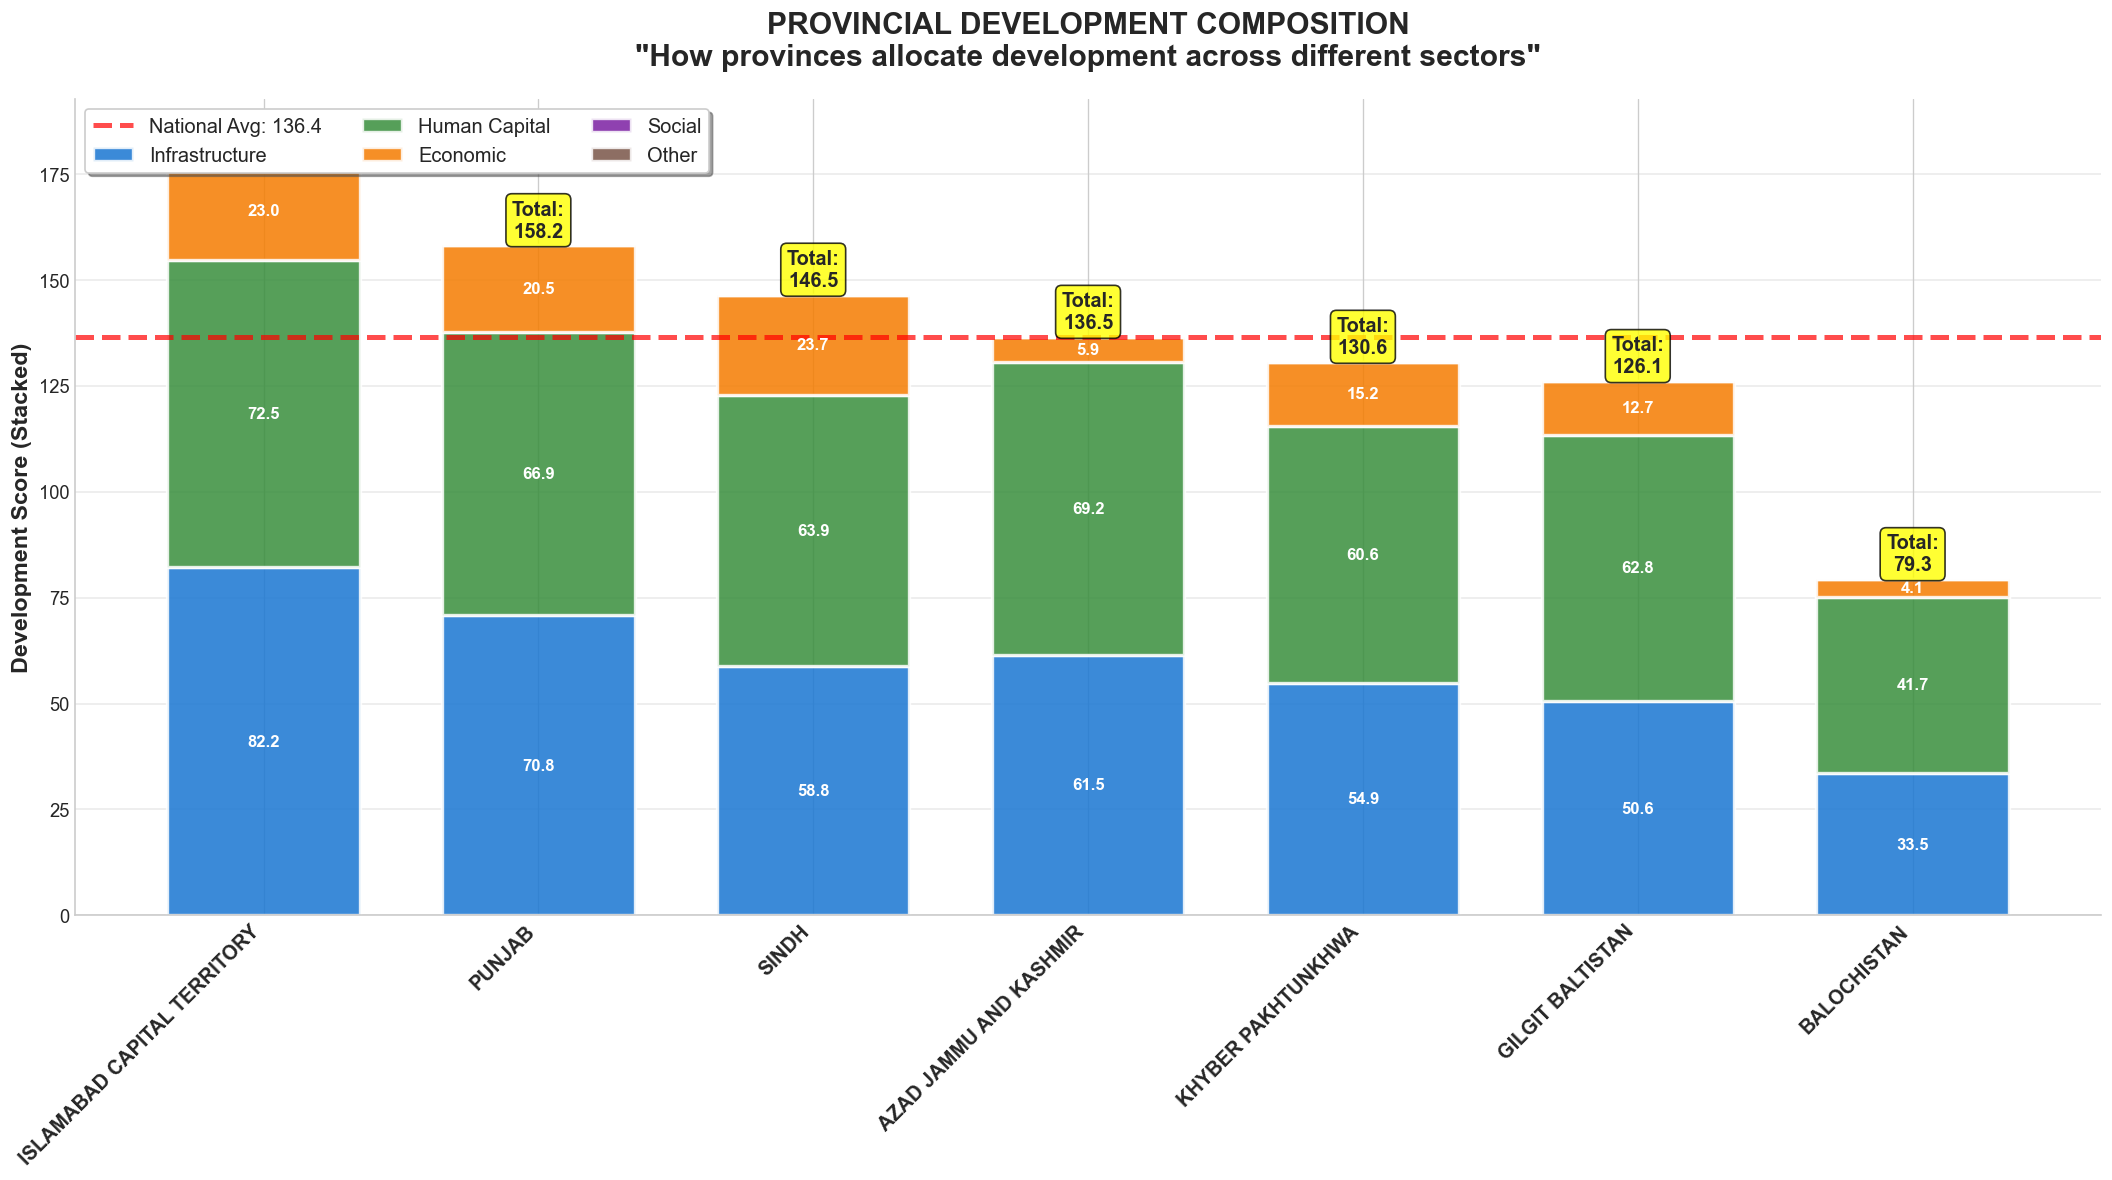


VISUALIZATION 1: Provincial Development Composition (Stacked Bars)


In [8]:
# Visualization 5A: Stacked Bar Chart - Provincial Composition
# Group dimensions into categories for better visualization
dimension_categories = {
    'Infrastructure': ['Housing_Amenities_Index', 'Infrastructure_Services_Index'],
    'Human Capital': ['Education_Index', 'Health_Index'],
    'Economic': ['Agriculture_Index', 'Industry_Index', 'Employment_Index'],
    'Social': ['Demographic_Index', 'Gender_Index'],
    'Other': ['Environment_Index', 'Technology_Index']
}

# Calculate provincial averages by category
province_composition = {}
provinces_list = df['Name of Province'].unique()

for prov in provinces_list:
    prov_data = df[df['Name of Province'] == prov]
    composition = {}
    
    for category, cols in dimension_categories.items():
        # Get columns that exist in the dataset
        existing_cols = [col for col in cols if col in index_cols]
        if existing_cols:
            composition[category] = prov_data[existing_cols].mean().mean()
        else:
            composition[category] = 0
    
    province_composition[prov] = composition

comp_df = pd.DataFrame(province_composition).T
# Sort provinces by total development score
comp_df = comp_df.loc[comp_df.sum(axis=1).sort_values(ascending=False).index]

# Main chart: Stacked bar chart
fig, ax_main = plt.subplots(figsize=(18, 10))

x_pos = np.arange(len(comp_df))
width = 0.7

# Color scheme for categories
colors_cat = {
    'Infrastructure': '#1976d2',
    'Human Capital': '#388e3c',
    'Economic': '#f57c00',
    'Social': '#7b1fa2',
    'Other': '#795548'
}

# Plot stacked bars
bottom = np.zeros(len(comp_df))
for category in comp_df.columns:
    values = comp_df[category].values
    bars = ax_main.bar(x_pos, values, width, bottom=bottom,
                       label=category, color=colors_cat.get(category, '#999999'),
                       alpha=0.85, edgecolor='white', linewidth=2)
    
    # Add value labels in the middle of each segment
    for i, (bar, val) in enumerate(zip(bars, values)):
        if val > 3:  # Only show label if segment is large enough
            height = bar.get_height()
            y_pos = bottom[i] + height/2
            ax_main.text(bar.get_x() + bar.get_width()/2, y_pos,
                        f'{val:.1f}', ha='center', va='center',
                        fontsize=10, fontweight='bold', color='white')
    
    bottom += values

# Add total scores on top
for i, (idx, row) in enumerate(comp_df.iterrows()):
    total = row.sum()
    ax_main.text(i, total + 2, f'Total:\n{total:.1f}',
                ha='center', fontsize=12, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

# Add national average line
nat_avg_total = comp_df.mean().sum()
ax_main.axhline(nat_avg_total, color='red', linestyle='--', linewidth=3,
               alpha=0.7, label=f'National Avg: {nat_avg_total:.1f}')

# Styling
ax_main.set_xticks(x_pos)
ax_main.set_xticklabels(comp_df.index, fontsize=12, fontweight='bold', rotation=45, ha='right')
ax_main.set_ylabel('Development Score (Stacked)', fontsize=14, fontweight='bold')
ax_main.set_title('PROVINCIAL DEVELOPMENT COMPOSITION\n"How provinces allocate development across different sectors"',
                 fontsize=18, fontweight='bold', pad=20)
ax_main.legend(fontsize=12, loc='upper left', frameon=True, shadow=True, ncol=3)
ax_main.grid(axis='y', alpha=0.4, linewidth=1)
ax_main.set_ylim(0, comp_df.sum(axis=1).max() + 15)
ax_main.spines['top'].set_visible(False)
ax_main.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("VISUALIZATION 1: Provincial Development Composition (Stacked Bars)")
print("="*70)

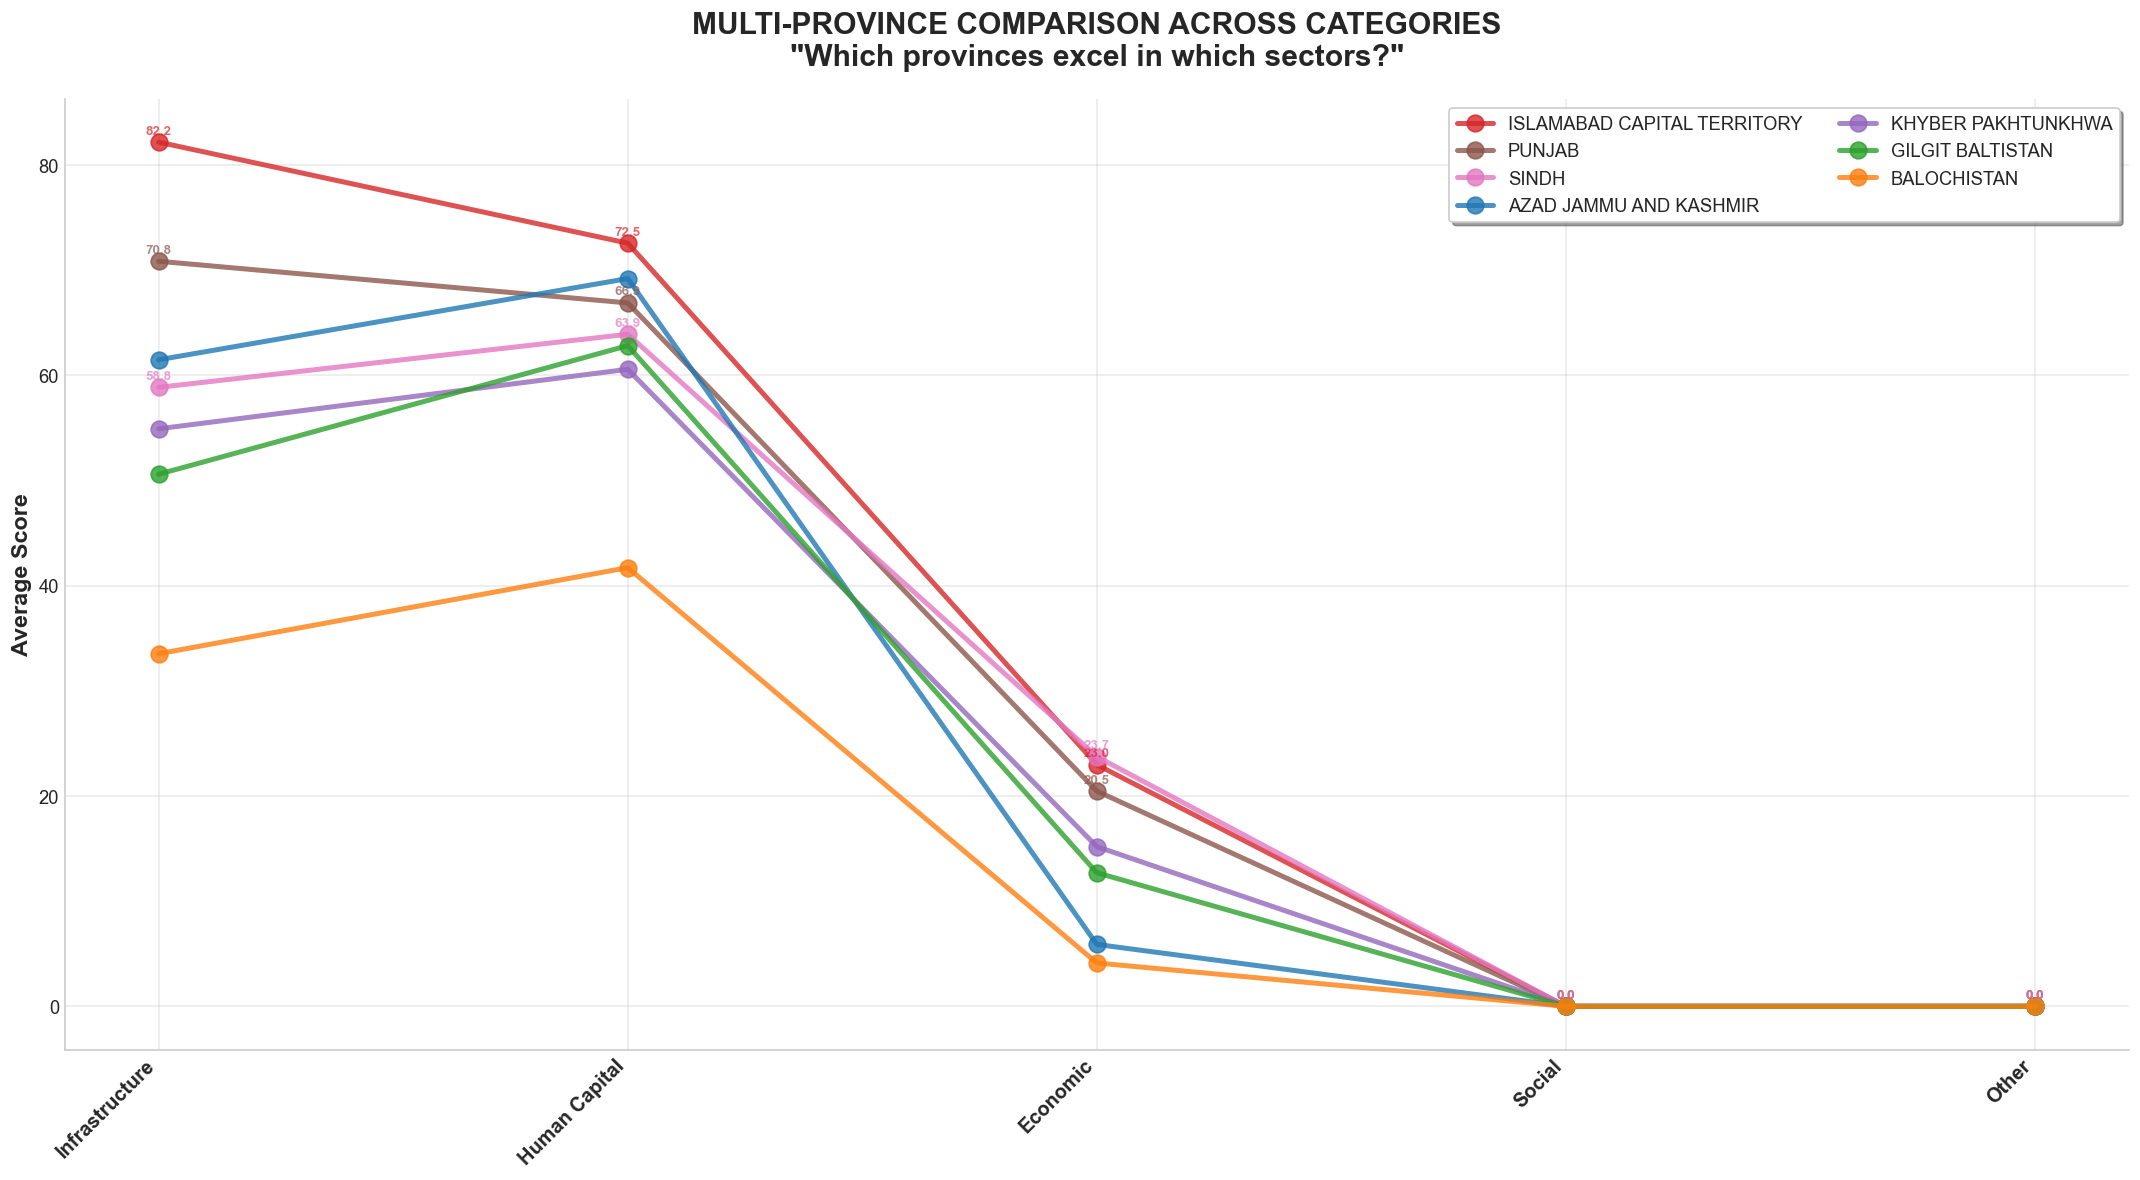


KEY FINDING #5: DIFFERENT PROVINCIAL PRIORITIES

Provinces have different development priorities and strengths.
Some excel in infrastructure, others in human capital or economic sectors.


In [9]:
# Visualization 5D: Multi-line Comparison Chart
fig, ax_lines = plt.subplots(figsize=(18, 10))

# Plot lines for each province across categories with consistent colors
for prov, row in comp_df.iterrows():
    line_color = PROVINCE_COLORS[prov]
    ax_lines.plot(range(len(row)), row.values, 'o-',
                 linewidth=3, markersize=10, label=prov,
                 color=line_color, alpha=0.8)
    
    # Add value labels at each point (for top 3 provinces only to avoid clutter)
    if list(comp_df.index).index(prov) < 3:
        for j, val in enumerate(row.values):
            ax_lines.text(j, val + 0.8, f'{val:.1f}',
                         ha='center', fontsize=8, fontweight='bold',
                         color=line_color, alpha=0.7)

ax_lines.set_xticks(range(len(comp_df.columns)))
ax_lines.set_xticklabels(comp_df.columns, fontsize=12, fontweight='bold',
                         rotation=45, ha='right')
ax_lines.set_ylabel('Average Score', fontsize=14, fontweight='bold')
ax_lines.set_title('MULTI-PROVINCE COMPARISON ACROSS CATEGORIES\n"Which provinces excel in which sectors?"',
                  fontsize=18, fontweight='bold', pad=20)
ax_lines.grid(True, alpha=0.4, linewidth=1)
ax_lines.spines['top'].set_visible(False)
ax_lines.spines['right'].set_visible(False)
ax_lines.legend(fontsize=11, loc='best', frameon=True, shadow=True, ncol=2)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("KEY FINDING #5: DIFFERENT PROVINCIAL PRIORITIES")
print("="*70)
print("\nProvinces have different development priorities and strengths.")
print("Some excel in infrastructure, others in human capital or economic sectors.")
print("="*70)

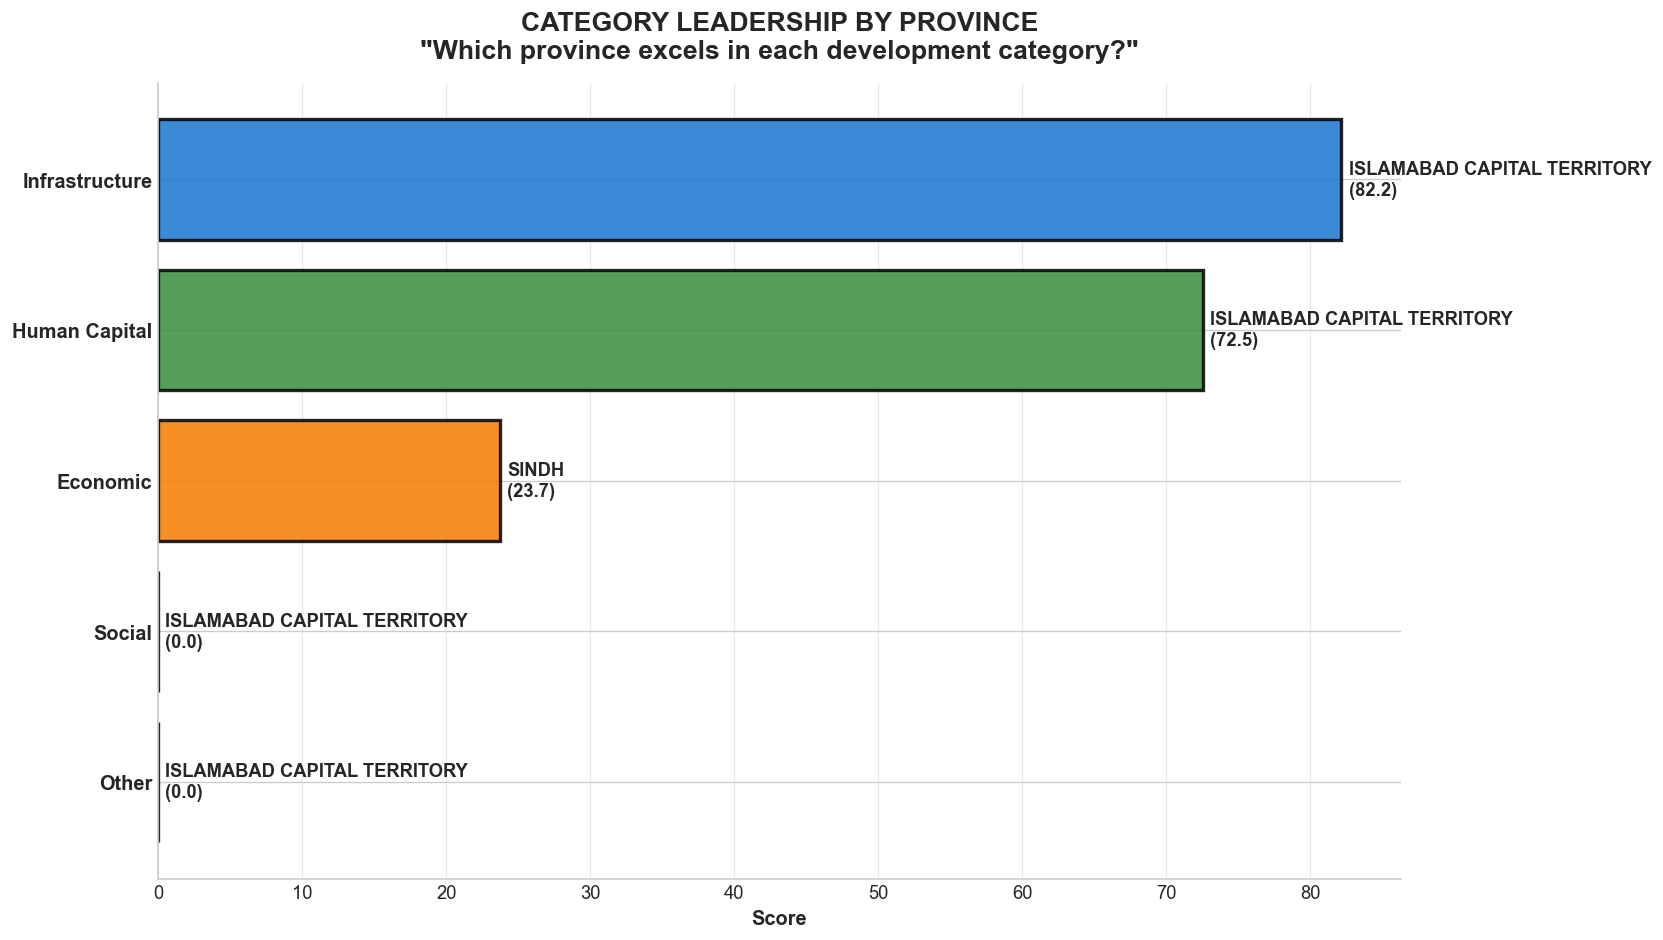


VISUALIZATION 3: Category Leadership Rankings
Infrastructure: ISLAMABAD CAPITAL TERRITORY leads with 82.2
Human Capital: ISLAMABAD CAPITAL TERRITORY leads with 72.5
Economic: SINDH leads with 23.7
Social: ISLAMABAD CAPITAL TERRITORY leads with 0.0
Other: ISLAMABAD CAPITAL TERRITORY leads with 0.0


In [10]:
# Visualization 5C: Category Leadership
fig, ax = plt.subplots(figsize=(14, 8))

# Find which province leads in each category
category_leaders = {}
for category in comp_df.columns:
    leader = comp_df[category].idxmax()
    score = comp_df[category].max()
    category_leaders[category] = (leader, score)

# Create bar chart showing leaders
categories = list(category_leaders.keys())
leaders = [category_leaders[cat][0] for cat in categories]
scores = [category_leaders[cat][1] for cat in categories]

y_pos = np.arange(len(categories))

bars = ax.barh(y_pos, scores, color=[colors_cat[cat] for cat in categories],
               alpha=0.85, edgecolor='black', linewidth=2)

# Add labels
for i, (bar, leader, score) in enumerate(zip(bars, leaders, scores)):
    ax.text(score + 0.5, i, f'{leader}\n({score:.1f})',
           va='center', fontsize=11, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(categories, fontsize=12, fontweight='bold')
ax.set_xlabel('Score', fontsize=12, fontweight='bold')
ax.set_title('CATEGORY LEADERSHIP BY PROVINCE\n"Which province excels in each development category?"',
            fontsize=16, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.4)
ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("VISUALIZATION 3: Category Leadership Rankings")
print("="*70)
for category, (leader, score) in category_leaders.items():
    print(f"{category}: {leader} leads with {score:.1f}")

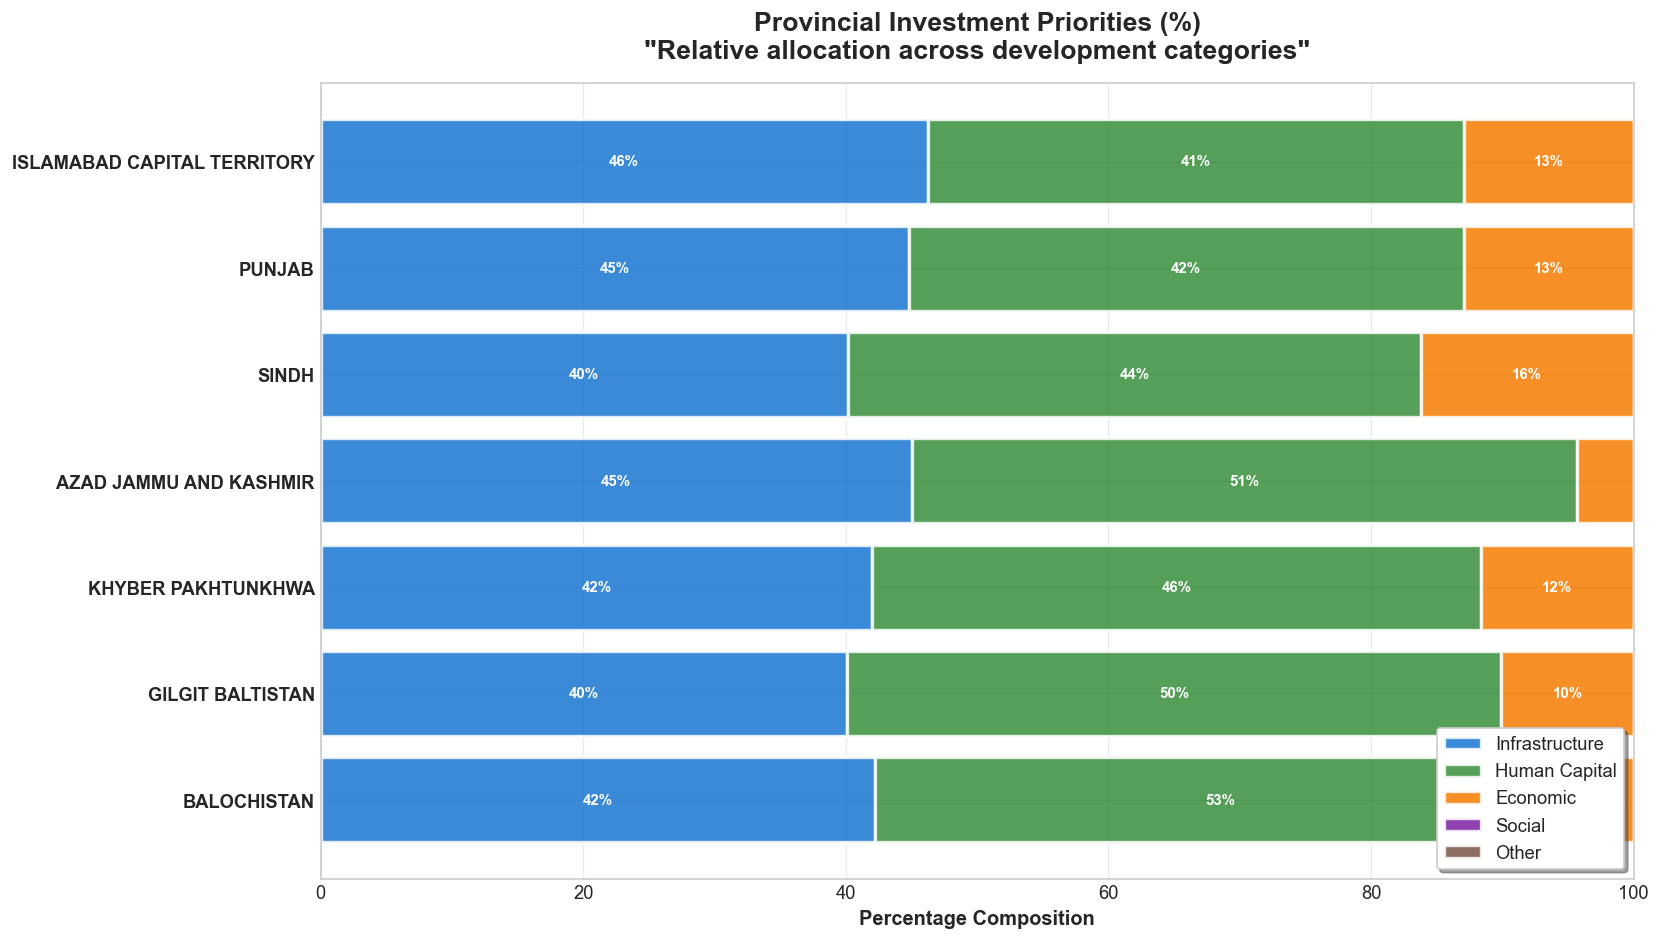


VISUALIZATION 2: Percentage Composition by Province


In [11]:
# Visualization 5B: Percentage Composition
fig, ax_pct = plt.subplots(figsize=(14, 8))

# Calculate percentage composition
comp_pct = comp_df.div(comp_df.sum(axis=1), axis=0) * 100

# Stacked percentage bars
bottom_pct = np.zeros(len(comp_pct))
for category in comp_pct.columns:
    values = comp_pct[category].values
    ax_pct.barh(range(len(comp_pct)), values, left=bottom_pct,
               label=category, color=colors_cat.get(category, '#999999'),
               alpha=0.85, edgecolor='white', linewidth=2)
    
    # Add percentage labels
    for i, val in enumerate(values):
        if val > 5:  # Only show if >5%
            x_pos_pct = bottom_pct[i] + val/2
            ax_pct.text(x_pos_pct, i, f'{val:.0f}%',
                       ha='center', va='center', fontsize=9,
                       fontweight='bold', color='white')
    
    bottom_pct += values

ax_pct.set_yticks(range(len(comp_pct)))
ax_pct.set_yticklabels(comp_pct.index, fontsize=11, fontweight='bold')
ax_pct.set_xlabel('Percentage Composition', fontsize=12, fontweight='bold')
ax_pct.set_title('Provincial Investment Priorities (%)\n"Relative allocation across development categories"',
                fontsize=16, fontweight='bold', pad=15)
ax_pct.set_xlim(0, 100)
ax_pct.invert_yaxis()
ax_pct.grid(axis='x', alpha=0.4)
ax_pct.legend(fontsize=11, loc='lower right', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("VISUALIZATION 2: Percentage Composition by Province")
print("="*70)

### 💡 WHAT THIS MEANS FOR POLICY

**The Challenge**: Provinces are not developing evenly across all sectors. Some focus heavily on infrastructure while neglecting human capital, others do the opposite.

**Why It Matters**:
- **Specialization**: Provinces may be specializing in certain areas
- **Gaps**: Some critical sectors are underfunded in certain provinces
- **Federal Role**: Federal government must ensure no sector is completely neglected
- **Best Practices**: Leading provinces in each category can mentor others

**Key Insight**: The stacked bars show total development, but the composition reveals priorities. A province might have a good total score but be heavily skewed toward one category.

### 📋 POLICY RECOMMENDATIONS

1. **Sectoral Balance Requirements**
   - No category should score below 30 in any province
   - Provinces must address their weakest category first
   - Federal funding conditional on balanced development

2. **Learn from Category Leaders**
   - Infrastructure leader shares best practices
   - Human Capital leader mentors struggling provinces
   - Create sector-specific working groups

3. **National Coordination**
   - Set minimum standards for each category
   - Provinces below standard get targeted support
   - Annual sectoral performance reviews

4. **Resource Reallocation**
   - Provinces over-investing in strong areas must shift focus
   - Federal incentives for addressing weak categories
   - "Catch-up" funds for provinces lagging in specific sectors

---